In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
import numpy as np
import torch
import pandas as pd
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import json
import math
import pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec

from matplotlib.patches import Rectangle

from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedAreaConfig, SpatiallyEmbeddedRNN
from bioplnn.datasets import Mazes
from bioplnn.utils import (
    initialize_dataloader,
)

maze_data_path = "/om2/user/jackking/torch-bioplnn-dev/data/mazes"
checkpoint_path = "/om2/user/jackking/torch-bioplnn-dev/train/checkpoints/"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

batch_size = 20

In [39]:
def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    

In [40]:
def combine_activations(activations, abs=True):
    if abs:
        return torch.mean(torch.abs(activations), dim=1)
    else:
        return torch.mean(activations, dim=1)

def visualize_activations(excitatory_activations, inhibitory_activations, maze):
    excitatory_activations = combine_activations(excitatory_activations)
    inhibitory_activations = combine_activations(inhibitory_activations)
    
    combined_activations = torch.sum(excitatory_activations - inhibitory_activations, dim = 0)
    return combined_activations

In [41]:
train_loader, test_loader = initialize_dataloader(
    seed=42, root="./data/mazes/", batch_size=batch_size, dataset="mazes"
)
inputs, labels = next(iter(test_loader))

wandb_name = "happy-microwave-331"
# wandb_name = "elated-moon-329"

try:
    full_config = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
    model_config = full_config["model_config"]
    num_steps = full_config["num_steps"]
except:
    model_config = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
    num_steps = 20

model = SpatiallyEmbeddedRNN(**model_config["rnn_kwargs"])
classifier = SpatiallyEmbeddedClassifier(**model_config)

mazes = Mazes(maze_data_path)

## Plot model progression on various inputs

In [ ]:
checkpoints = [0, 10, 27, 80]

for input,label in zip(inputs, labels):
    maze = mazes.tensor_to_image(input)
    plt.imshow(maze)
    plt.show()
    fig, axs = plt.subplots(int(len(checkpoints)/2), 2, figsize=(10, 10))
    for epoch, ax in zip(checkpoints, axs.flatten()):
        try:
            state_dict = torch.load(checkpoint_path + f"{wandb_name}/{epoch}.pth")
        except:
            state_dict = torch.load(checkpoint_path + f"{wandb_name}_{epoch}.pth")
        rnn_weights = prepare_rnn_weights(state_dict)
        model.load_state_dict(rnn_weights)
        classifier.load_state_dict(state_dict)
        output_states, neuron_states, feedback_states = model(input.unsqueeze(0), num_steps=num_steps)
        classifier_output = classifier(input.unsqueeze(0), num_steps=num_steps)
        correct = torch.argmax(classifier_output, dim=1) == label
        excitatory_activations = model.query_neuron_states(neuron_states, 0, 0).detach().cpu()[0]
        inhibitory_activations = model.query_neuron_states(neuron_states, 0, 1).detach().cpu()[0]
        image = visualize_activations(excitatory_activations, inhibitory_activations, input)
        im = ax.imshow(image)
        ax.set_title(f"Epoch {epoch} - Correct: {correct.item()}")
    plt.tight_layout()
    fig.colorbar(im, ax=axs.ravel().tolist())
    plt.show()

## Plot one model on multiple inputs

In [ ]:
epoch = 200
num_inputs = len(inputs)
fig, axs = plt.subplots(num_inputs, 2, figsize=(10, 5*num_inputs))

try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{epoch}.pth")
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{epoch}.pth")
    
rnn_weights = prepare_rnn_weights(state_dict)
model.load_state_dict(rnn_weights)
classifier.load_state_dict(state_dict)

for i, (input, label) in enumerate(zip(inputs, labels)):
    # Plot maze
    maze = mazes.tensor_to_image(input)
    axs[i, 0].imshow(maze)
    axs[i, 0].set_title(f"Input {i+1} - Maze")
    axs[i, 0].axis('off')
    
    # Get activations and plot
    output_states, neuron_states, feedback_states = model(input.unsqueeze(0), num_steps=num_steps)
    classifier_output = classifier(input.unsqueeze(0), num_steps=num_steps)
    correct = torch.argmax(classifier_output, dim=1) == label
    
    excitatory_activations = model.query_neuron_states(neuron_states, 0, 0).detach().cpu()[0]
    image = combine_activations(excitatory_activations)
    num_steps = image.shape[0]

    subfig, subaxs = plt.subplots(3, 3, figsize=(10, 10))
    for j in range(0, num_steps, 3):
        subaxs[j//3, j%3].imshow(image[j], cmap='viridis')
        subaxs[j//3, j%3].set_title(f"Step {j}")
        subaxs[j//3, j%3].axis('off')

plt.tight_layout()
fig.colorbar(im, ax=axs.ravel().tolist())
plt.show()

## Plot the progression of actvity over steps for a few inputs

In [ ]:
epoch = 200
num_inputs = len(inputs)
fig = plt.figure(figsize=(10, 5*num_inputs))

try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{epoch}.pth")
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{epoch}.pth")
            
rnn_weights = prepare_rnn_weights(state_dict)
model.load_state_dict(rnn_weights)
classifier.load_state_dict(state_dict)

for i, (input, label) in enumerate(zip(inputs, labels)):
    # Create grid for this row
    gs = fig.add_gridspec(num_inputs, 2, width_ratios=[1, 3], height_ratios=[1]*num_inputs)
    
    # Plot maze in first column
    ax_maze = fig.add_subplot(gs[i, 0])
    maze = mazes.tensor_to_image(input)
    ax_maze.imshow(maze)

    classifier_output = classifier(input.unsqueeze(0), num_steps=num_steps)
    correct = torch.argmax(classifier_output, dim=1) == label

    if label == 0:
        title = f"No Path"
    else:
        title = f"Path"
    
    if correct:
        title += " - Correct"
    else:
        title += " - Incorrect"
    
    ax_maze.set_title(title)
    ax_maze.axis('off')
    
    # Get activations
    output_states, neuron_states, feedback_states = model(input.unsqueeze(0), num_steps=num_steps)
    excitatory_activations = model.query_neuron_states(neuron_states, 0, 0).detach().cpu()[0]
    # inhibitory_activations = model.query_neuron_states(neuron_states, 0, 1).detach().cpu()[0]
    image = combine_activations(excitatory_activations)
    num_steps = image.shape[0]

    # Create nxm subgrid for activations in second column
    n, m = 3, 3  # Parameterized grid size
    sub_gs = gs[i, 1].subgridspec(n, m, hspace=0.1)
    
    # Plot activation steps - evenly spaced across all available steps
    step_indices = np.linspace(0, num_steps-1, n*m, dtype=int)
    for j, step_idx in enumerate(step_indices):
        row, col = j // m, j % m
        ax = fig.add_subplot(sub_gs[row, col])
        im = ax.imshow(image[step_idx], cmap='viridis')
        ax.set_title(f"Step {step_idx}")
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
checkpoints = [10, 50, 200]

num_inputs = len(inputs)
fig = plt.figure(figsize=(10, 5*len(checkpoints)*num_inputs))

for i, (input, label) in enumerate(zip(inputs, labels)):
    for epoch_idx, epoch in enumerate(checkpoints):

        try:
            state_dict = torch.load(checkpoint_path + f"{wandb_name}/{epoch}.pth")
        except:
            state_dict = torch.load(checkpoint_path + f"{wandb_name}_{epoch}.pth")
            
        rnn_weights = prepare_rnn_weights(state_dict)
        model.load_state_dict(rnn_weights)
        classifier.load_state_dict(state_dict)

        figure_index = i*len(checkpoints) + epoch_idx
        print(figure_index)

        # Create grid for this row
        gs = fig.add_gridspec(num_inputs*len(checkpoints), 2, width_ratios=[1, 3], height_ratios=[1]*num_inputs*len(checkpoints))
        
        # Plot maze in first column
        ax_maze = fig.add_subplot(gs[figure_index, 0])
        maze = mazes.tensor_to_image(input)
        ax_maze.imshow(maze)

        classifier_output = classifier(input.unsqueeze(0), num_steps=num_steps)
        correct = torch.argmax(classifier_output, dim=1) == label

        if label == 0:
            title = f"No Path"
        else:
            title = f"Path"
        
        if correct:
            title += " - Correct"
        else:
            title += " - Incorrect"

        title += f" - Epoch {epoch}"
        
        ax_maze.set_title(title)
        ax_maze.axis('off')
        
        # Get activations
        output_states, neuron_states, feedback_states = model(input.unsqueeze(0), num_steps=num_steps)
        excitatory_activations = model.query_neuron_states(neuron_states, 0, 0).detach().cpu()[0]
        # inhibitory_activations = model.query_neuron_states(neuron_states, 0, 1).detach().cpu()[0]
        image = combine_activations(excitatory_activations)
        num_steps = image.shape[0]

        # Create nxm subgrid for activations in second column
        n, m = 3, 3  # Parameterized grid size
        sub_gs = gs[figure_index, 1].subgridspec(n, m, hspace=0.1)
        
        # Plot activation steps - evenly spaced across all available steps
        step_indices = np.linspace(0, num_steps-1, n*m, dtype=int)
        for j, step_idx in enumerate(step_indices):
            row, col = j // m, j % m
            ax = fig.add_subplot(sub_gs[row, col])
            im = ax.imshow(image[step_idx], cmap='viridis')
            ax.set_title(f"Step {step_idx}")
            ax.axis('off')

plt.tight_layout()
plt.show()

## For one model: Plotting mean abs activity for a selection of mazes, over a selection of epochs, and over steps.

In [ ]:
wandb_name = ""
# wandb_name = "elated-moon-329"
wandb_name = "twilight-spaceship-341"
checkpoints = [390]

# wandb_name = "happy-microwave-331"
# checkpoints = [200]

# wandb_name = "azure-blaze-362"
# checkpoints = [130]

# wandb_name = "dandy-brook-358"
# checkpoints = [490]

# wandb_name = "fiery-planet-379"
# checkpoints = [470]

try:
    full_config = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
    model_config = full_config["model_config"]
    num_steps = full_config["num_steps"]
except:
    model_config = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
    num_steps = 20

model = SpatiallyEmbeddedRNN(**model_config["rnn_kwargs"])
classifier = SpatiallyEmbeddedClassifier(**model_config)
# inputs, labels = next(iter(train_loader))

mazes = Mazes(maze_data_path)

num_inputs = len(inputs)
n, m = 2, 2 # inner activation grid size
excitatory = True

plot_maze = True  # <— set False to drop the left maze column

num_cols = len(checkpoints) + (1 if plot_maze else 0)
fig = plt.figure(figsize=(3 * num_cols * m, 7 * num_inputs))
outer_gs = fig.add_gridspec(
    num_inputs,
    num_cols,
    width_ratios=(([1] if plot_maze else []) + [2] * len(checkpoints)),
    wspace=0.2,
)

maze_offset = 1 if plot_maze else 0  # how many columns are before activations

# inputs, labels = [inputs[0]], [labels[0]]

for i, (input_tensor, label) in enumerate(zip(inputs, labels)):
    # ——— Maze once per row ———
    if plot_maze:
        ax_maze = fig.add_subplot(outer_gs[i, 0])
        maze_img = mazes.tensor_to_image(input_tensor)
        ax_maze.imshow(maze_img)
        ax_maze.set_title(f"Sample {i}", fontsize=10)
        ax_maze.axis('off')

    for j, epoch in enumerate(checkpoints):
        # load model & classifier
        try:
            state_dict = torch.load(checkpoint_path + f"{wandb_name}/{epoch}.pth")
        except:
            state_dict = torch.load(checkpoint_path + f"{wandb_name}_{epoch}.pth")

        model.load_state_dict(prepare_rnn_weights(state_dict))
        classifier.load_state_dict(state_dict)

        out = classifier(input_tensor.unsqueeze(0), num_steps=num_steps)
        correct = (out.argmax(dim=1).item() == label)

        _, neuron_states, _ = model(input_tensor.unsqueeze(0), num_steps=num_steps)
        act = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1).detach().cpu()[0]
        images = combine_activations(act, abs=True)
        total_steps = images.shape[0]

        col = j + maze_offset
        sub_gs = outer_gs[i, col].subgridspec(n, m, hspace=0.1, wspace=0.1)
        step_idxs = np.linspace(0, total_steps - 1, n * m, dtype=int)
        subset = images[step_idxs]
        vmin, vmax = subset.min(), subset.max()

        for k, step in enumerate(step_idxs):
            r, c = divmod(k, m)
            ax = fig.add_subplot(sub_gs[r, c])
            ax.imshow(
                images[step],
                cmap='viridis',
                vmin=vmin,
                vmax=vmax
            )
            ax.axis('off')

            title = f"Step {step}"
            if step == 0:
                status = "✓" if correct else "✗"
                title += f" - E{epoch} {status}"
            ax.set_title(title, fontsize=8)

plt.tight_layout()
# if excitatory:
#     plt.savefig(f"/om2/user/jackking/torch-bioplnn-dev/scripts/activations/{wandb_name}_excitatory_activations.png")
# else:
#     plt.savefig(f"/om2/user/jackking/torch-bioplnn-dev/scripts/activations/{wandb_name}_inhibitory_activations.png")
plt.show()

## Instead of taking the mean, we're going to plot all the channels sepearately, 

In [ ]:
wandb_name = ""
# wandb_name = "elated-moon-329"
wandb_name = "twilight-spaceship-341"
checkpoint = 390

# wandb_name = "happy-microwave-331"
# checkpoints = [200]

# wandb_name = "azure-blaze-362"
# checkpoints = [130]

# wandb_name = "dandy-brook-358"
# checkpoints = [490]

# wandb_name = "fiery-planet-379"
# checkpoints = [470]

try:
    full_config = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
    model_config = full_config["model_config"]
    num_steps = full_config["num_steps"]
except:
    model_config = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
    num_steps = 20

model = SpatiallyEmbeddedRNN(**model_config["rnn_kwargs"])
classifier = SpatiallyEmbeddedClassifier(**model_config)
# inputs, labels = next(iter(train_loader))
mazes = Mazes(maze_data_path)

# load model & classifier
try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth")
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth")

model.load_state_dict(prepare_rnn_weights(state_dict))
classifier.load_state_dict(state_dict)

_, neuron_states, _ = model(inputs[0].unsqueeze(0), num_steps=num_steps)
act = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1).detach().cpu()[0]
total_steps = act.shape[0]

num_inputs = len(inputs)
n, m = 2, 2 # inner activation grid size
excitatory = True

plot_maze = True  # <— set False to drop the left maze column

num_cols = act.shape[1] + (1 if plot_maze else 0)
fig = plt.figure(figsize=(3 * num_cols * m, 7 * num_inputs))
outer_gs = fig.add_gridspec(
    num_inputs,
    num_cols,
    width_ratios=(([1] if plot_maze else []) + [2] * act.shape[1]),
    wspace=0.2,
)

maze_offset = 1 if plot_maze else 0  # how many columns are before activations

# inputs, labels = [inputs[0]], [labels[0]]

for i, (input_tensor, label) in enumerate(zip(inputs, labels)):

    out = classifier(input_tensor.unsqueeze(0), num_steps=num_steps)
    correct = (out.argmax(dim=1).item() == label)

    _, neuron_states, _ = model(input_tensor.unsqueeze(0), num_steps=num_steps)
    act = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1).detach().cpu()[0]

    vmin, vmax = act.flatten().min(), act.flatten().max()

    # ——— Maze once per row ———
    if plot_maze:
        ax_maze = fig.add_subplot(outer_gs[i, 0])
        maze_img = mazes.tensor_to_image(input_tensor)
        ax_maze.imshow(maze_img)
        ax_maze.set_title(f"Sample {i}", fontsize=10)
        ax_maze.axis('off')

    for j in range(act.shape[1]):
        
        images = act[:, j]
        col = j + maze_offset
        sub_gs = outer_gs[i, col].subgridspec(n, m, hspace=0.1, wspace=0.1)
        step_idxs = np.linspace(0, total_steps - 1, n * m, dtype=int)

        for k, step in enumerate(step_idxs):
            r, c = divmod(k, m)
            ax = fig.add_subplot(sub_gs[r, c])
            ax.imshow(
                images[step],
                cmap='viridis',
                vmin=vmin,
                vmax=vmax
            )
            ax.axis('off')

            title = f"Step {step}"
            if step == 0:
                status = "✓" if correct else "✗"
                title += f" - Channel {j} {status}"
            ax.set_title(title, fontsize=8)

plt.tight_layout()
# if excitatory:
#     plt.savefig(f"/om2/user/jackking/torch-bioplnn-dev/scripts/activations/{wandb_name}_excitatory_activations.png")
# else:
#     plt.savefig(f"/om2/user/jackking/torch-bioplnn-dev/scripts/activations/{wandb_name}_inhibitory_activations.png")
plt.show()

In [ ]:
wandb_name = "happy-microwave-331"
epoch = 10

# wandb_name = "azure-blaze-362"
# eooch = 130

wandb_name = "twilight-spaceship-341"
epoch = 390

try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{epoch}.pth")
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{epoch}.pth")
    
for key in state_dict.keys():
    if "convs" in key and "weight" in key:
        print(key)
        weight = state_dict[key].detach().cpu()
        print(weight.shape)
        total_kernels = weight.shape[0] * weight.shape[1]
        weights = weight.reshape(total_kernels, weight.shape[2], weight.shape[3])
        width = math.ceil(math.sqrt(total_kernels))
        height = math.ceil(total_kernels / width)
        fig, axs = plt.subplots(height, width, figsize=(10, 10), 
                               gridspec_kw={'hspace': 0.1, 'wspace': 0.1})
        for kernel in range(total_kernels):
            axs[kernel//width, kernel%width].imshow(weights[kernel], cmap='viridis')
            axs[kernel//width, kernel%width].axis('off')
        fig.suptitle(key)
        plt.tight_layout()
        plt.show()

## Plotting Input->E and E->E together

In [ ]:
# ——— User‐set paths & names ———
wandb_name    = "twilight-spaceship-341"
checkpoint    = 390    # also used as epoch

# wandb_name = "happy-microwave-331"
# checkpoint = 200


# ——— Load model config & instantiate ———
try:
    full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
    model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
except:
    model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
    num_steps = 20

model      = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
classifier = SpatiallyEmbeddedClassifier(**model_cfg)
mazes      = Mazes(maze_data_path)

# ——— Load checkpoint & weights ———
state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
model.load_state_dict(prepare_rnn_weights(state_dict))
classifier.load_state_dict(state_dict)

# ——— Plot settings ———
excitatory = True
input_channel = -1 #0 is walls, -1 is starting points
plot_maze  = True
n, m       = 3,3   # activity grid dims
σ_filter   = 1.0    # optional blur for weights

# ——— Extract weight‐matrices & taus ———
if excitatory:
    # conv0 input→e filters: shape (out_chan, in_chan, H, W)
    conv0 = state_dict["rnn.areas.0.convs.0->0.0.weight"].detach().cpu().numpy()
    # conv1 e→e filters: shape (K, C, H, W)
    e2e = state_dict["rnn.areas.0.convs.1->0.0.weight"].detach().cpu().numpy()
    # tau constants per channel
    taus = state_dict["rnn.areas.0.tau.0"].detach().cpu().numpy()[0, :, 0, 0]  # (C,)
else:
    conv0 = state_dict["rnn.areas.0.convs.0->1.0.weight"].detach().cpu().numpy()
    e2e = state_dict["rnn.areas.0.convs.2->0.0.weight"].detach().cpu().numpy()
    taus = state_dict["rnn.areas.0.tau.1"].detach().cpu().numpy()[0, :, 0, 0]  # (C,)

input_filters = conv0[:, input_channel]                # ⇒ (C, H, W)

# Precompute channel count & e→e kernel grid
C = input_filters.shape[0]
# Note: we'll re‐compute K, kern_cols/rows per channel if you switch 'output' flag.
output = False  # if True: kernels = e2e[:, j], else: kernels = e2e[j, :]

# Number of columns for activity: one per channel (+1 for maze)
num_cols = C + 1 + (1 if plot_maze else 0)
num_inputs = len(inputs)

fig = plt.figure(figsize=(3 * num_cols * m, 15 * num_inputs))
outer = fig.add_gridspec(
    num_inputs, num_cols,
    width_ratios=([1] if plot_maze else []) + [2] * C,
    hspace=0.2, wspace=0.1
)

#blur kernels
full_wvmin, full_wvmax = np.inf, -np.inf
for j in range(C):
    # choose this channel’s e→e kernels
    kernels = e2e[:, j] if output else e2e[j, :]
    for k in range(len(kernels)):
        kernels[k] = gaussian_filter(kernels[k], sigma=σ_filter)
    wvmin, wvmax = kernels.min(), kernels.max()
    full_wvmin = min(full_wvmin, wvmin)
    full_wvmax = max(full_wvmax, wvmax)
wvmin, wvmax = full_wvmin, full_wvmax

wf = gaussian_filter(input_filters, sigma=σ_filter)
wf_vmin, wf_vmax = wf.min(), wf.max()

for i, (inp, label) in enumerate(zip(inputs, labels)):
    # ——— compute activity for sample i ———
    out = classifier(inp.unsqueeze(0), num_steps=num_steps)
    correct = (out.argmax(dim=1).item() == label)

    _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps)
    act = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
               .detach().cpu()[0]   # shape (T, C)
    T = act.shape[0]
    step_idxs = np.linspace(0, T - 1, n * m, dtype=int)

    # plot maze if desired
    col0 = 0
    if plot_maze:
        axm = fig.add_subplot(outer[i, 0])
        axm.imshow(mazes.tensor_to_image(inp))
        axm.set_title(f"Sample {i} {" ✓" if correct else " ✗"}", fontsize=10)
        axm.axis("off")
        col0 = 1
    
    #PLOT MEAN ACTIVITY PANEL HERE
    mean_act = torch.mean(act, axis=1)
    col0 += 1

    # ——— for each channel j, make a little stacked tower ———
    for j in range(C):
        col = j + col0

        # choose this channel’s e→e kernels
        kernels = e2e[:, j] if output else e2e[j, :]
        K = kernels.shape[0]
        kern_cols = m
        kern_rows = math.ceil(K / kern_cols)
        total_cols = m

        # sub‐grid: n rows of activity + 1 row for the conv0 filter + kern_rows for e→e
        total_rows = n + 1 + kern_rows
        # total_cols = max(m, kern_cols)

        # shrink the spaces here:
        sub = outer[i, col].subgridspec(
            total_rows, total_cols,
            height_ratios=[1]*n + [0.5] + [0.5]*kern_rows,  # make the filter row a bit shorter
            hspace=0.2,   # ↓ very little vertical padding
            wspace=0.02    # ↓ very little horizontal padding
        )

        # — Activity panels —
        vmin, vmax = act.flatten().min(), act.flatten().max()
        ims = []
        axs = []
        for k, step in enumerate(step_idxs):
            r, c = divmod(k, m)
            ax = fig.add_subplot(sub[r, c])
            im = ax.imshow(act[step, j], cmap='viridis', vmin=vmin, vmax=vmax)
            print(any(x < 0 for x in act[step, j].flatten()))
            ims.append(im)
            axs.append(ax)
            ax.axis('off')
            title = f"S{step}"
            ax.set_title(title, fontsize=8)

        # Add a colorbar for the activity panels (one per channel, rightmost activity panel)
        # Place colorbar to the right of the last activity panel in this channel
        # Only add one colorbar per channel
        if len(axs) > 0:
            # The last activity panel for this channel
            cbar_ax = axs[-1]
            plt.colorbar(ims[-1], ax=cbar_ax, fraction=0.046, pad=0.04)

        ax_col_title = fig.add_subplot(outer[0, col])
        ax_col_title.axis('off')
        ax_col_title.set_title(f"Channel {j}", fontsize=12, pad=20)

        # — Input‐filter weight (conv0) —
        wf = gaussian_filter(input_filters[j], sigma=σ_filter)
        wf_vmin, wf_vmax = wf.min(), wf.max()
        axf = fig.add_subplot(sub[n, :])
        im_wf = axf.imshow(wf, cmap='viridis', vmin=wf_vmin, vmax=wf_vmax)
        axf.set_title(f"τ={taus[j]:.3f}", fontsize=10)
        axf.axis('off')
        # if j == C-1:
        #     # Add colorbar for input filter
        #     plt.colorbar(im_wf, ax=axf, fraction=0.046, pad=0.04)

        # — e→e kernels —
        for k in range(len(kernels)):
            kernels[k] = gaussian_filter(kernels[k], sigma=σ_filter)
        wvmin, wvmax = kernels.min(), kernels.max()

        kernel_ims = []
        kernel_axs = []
        for k in range(len(kernels)):
            rr = n + 1 + (k // kern_cols)
            cc = k % kern_cols
            axk = fig.add_subplot(sub[rr, cc])
            imk = axk.imshow(kernels[k], cmap='viridis', vmin=wvmin, vmax=wvmax)
            kernel_ims.append(imk)
            kernel_axs.append(axk)
            axk.set_xticks([]); axk.set_yticks([])

            # highlight the "self" kernel
            if k == j:
                for side in axk.spines:
                    spine = axk.spines[side]
                    spine.set_visible(True)
                    spine.set_edgecolor('red')
                    spine.set_linewidth(1.5)
            else:
                for spine in axk.spines.values():
                    spine.set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# ——— User‐set paths & names ———
wandb_name    = "twilight-spaceship-341"
checkpoint    = 390    # also used as epoch

# wandb_name = "happy-microwave-331"
# checkpoint = 200


# ——— Load model config & instantiate ———
try:
    full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
    model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
except:
    model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
    num_steps = 20

model      = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
classifier = SpatiallyEmbeddedClassifier(**model_cfg)
mazes      = Mazes(maze_data_path)

# ——— Load checkpoint & weights ———
state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
model.load_state_dict(prepare_rnn_weights(state_dict))
classifier.load_state_dict(state_dict)

# ——— Plot settings ———
excitatory = True
input_channel = -1 #0 is walls, -1 is starting points
plot_maze  = True
n, m       = 3, 3   # activity grid dims
σ_filter   = 1.0    # optional blur for weights
output = False  # if True: kernels = e2e[:, j], else: kernels = e2e[j, :]

# ——— Extract weight‐matrices & taus ———
if excitatory:
    # conv0 input→e filters: shape (out_chan, in_chan, H, W)
    conv0 = state_dict["rnn.areas.0.convs.0->0.0.weight"].detach().cpu().numpy()
    # conv1 e→e filters: shape (K, C, H, W)
    e2e = state_dict["rnn.areas.0.convs.1->0.0.weight"].detach().cpu().numpy()
    # tau constants per channel
    taus = state_dict["rnn.areas.0.tau.0"].detach().cpu().numpy()[0, :, 0, 0]  # (C,)
else:
    conv0 = state_dict["rnn.areas.0.convs.0->1.0.weight"].detach().cpu().numpy()
    e2e = state_dict["rnn.areas.0.convs.2->0.0.weight"].detach().cpu().numpy()
    taus = state_dict["rnn.areas.0.tau.1"].detach().cpu().numpy()[0, :, 0, 0]  # (C,)

input_filters = conv0[:, input_channel]                # ⇒ (C, H, W)

# Precompute channel count & e→e kernel grid
C = input_filters.shape[0]

# Number of columns for activity: one per channel (+1 for maze)
num_cols = C + 1 + (1 if plot_maze else 0)
num_inputs = len(inputs)

fig = plt.figure(figsize=(3 * num_cols * m, 15 * num_inputs))
outer = fig.add_gridspec(
    num_inputs, num_cols,
    width_ratios=([1, 1.5] if plot_maze else [1.5]) + [2] * C,
    hspace=0.2, wspace=0.1
)

#blur kernels
full_wvmin, full_wvmax = np.inf, -np.inf
for j in range(C):
    # choose this channel’s e→e kernels
    kernels = e2e[:, j] if output else e2e[j, :]
    for k in range(len(kernels)):
        kernels[k] = gaussian_filter(kernels[k], sigma=σ_filter)
    wvmin, wvmax = kernels.min(), kernels.max()
    full_wvmin = min(full_wvmin, wvmin)
    full_wvmax = max(full_wvmax, wvmax)
wvmin, wvmax = full_wvmin, full_wvmax

wf = gaussian_filter(input_filters, sigma=σ_filter)
wf_vmin, wf_vmax = wf.min(), wf.max()

for i, (inp, label) in enumerate(zip(inputs, labels)):
    # ——— compute activity for sample i ———
    out = classifier(inp.unsqueeze(0), num_steps=num_steps)
    correct = (out.argmax(dim=1).item() == label)

    _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps)
    act = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
               .detach().cpu()[0]   # shape (T, C)
    T = act.shape[0]
    step_idxs = np.linspace(0, T - 1, n * m, dtype=int)

    # plot maze if desired
    col0 = 0
    if plot_maze:
        axm = fig.add_subplot(outer[i, 0])
        axm.imshow(mazes.tensor_to_image(inp))
        axm.set_title(f"Sample {i} {" ✓" if correct else " ✗"}", fontsize=10)
        axm.axis("off")
        col0 = 1
    
    # ——— compute mean activity across all C channels ———
    # act has shape (T, C, H, W), so this yields (T, H, W)
    mean_act = torch.mean(act, dim=1)

    # ——— plot mean‐activity subgrid at column col0 ———
    mean_col = col0
    # create an n×m sub‐gridspec for the mean‐activity panels
    mean_sub = outer[i, mean_col].subgridspec(
        n, m,
        height_ratios=[1]*n,
        hspace=0,
        wspace=0.02
    )

    # determine color‐scale from this sample’s mean activity
    mean_vmin, mean_vmax = mean_act.min(), mean_act.max()
    mean_ims, mean_axs = [], []
    for k, step in enumerate(step_idxs):
        r, c = divmod(k, m)
        ax_mean = fig.add_subplot(mean_sub[r, c])
        im_mean = ax_mean.imshow(mean_act[step], cmap='viridis',
                                vmin=mean_vmin, vmax=mean_vmax)
        ax_mean.axis('off')
        ax_mean.set_title(f"S{step}", fontsize=8)
        mean_ims.append(im_mean)
        mean_axs.append(ax_mean)

    # put a column title
    ax_mtitle = fig.add_subplot(outer[0, mean_col])
    ax_mtitle.axis('off')
    ax_mtitle.set_title("Mean Activity", fontsize=12, pad=20)
    col0 += 1

    # ——— for each channel j, make a little stacked tower ———
    for j in range(C):
        col = j + col0

        # choose this channel’s e→e kernels
        kernels = e2e[:, j] if output else e2e[j, :]
        K = kernels.shape[0]
        kern_cols = m
        kern_rows = math.ceil(K / kern_cols)
        total_cols = m

        # sub‐grid: n rows of activity + 1 row for the conv0 filter + kern_rows for e→e
        total_rows = n + 1 + kern_rows
        # total_cols = max(m, kern_cols)

        # shrink the spaces here:
        sub = outer[i, col].subgridspec(
            total_rows, total_cols,
            height_ratios=[1]*n + [0.5] + [0.5]*kern_rows,  # make the filter row a bit shorter
            hspace=0.2,   # ↓ very little vertical padding
            wspace=0.02    # ↓ very little horizontal padding
        )

        # — Activity panels —
        vmin, vmax = act.flatten().min(), act.flatten().max()
        ims = []
        axs = []
        for k, step in enumerate(step_idxs):
            r, c = divmod(k, m)
            ax = fig.add_subplot(sub[r, c])
            im = ax.imshow(act[step, j], cmap='viridis', vmin=vmin, vmax=vmax)
            ims.append(im)
            axs.append(ax)
            ax.axis('off')
            title = f"S{step}"
            ax.set_title(title, fontsize=8)

        # Add a colorbar for the activity panels (one per channel, rightmost activity panel)
        # Place colorbar to the right of the last activity panel in this channel
        # Only add one colorbar per channel
        if len(axs) > 0:
            # The last activity panel for this channel
            cbar_ax = axs[-1]
            plt.colorbar(ims[-1], ax=cbar_ax, fraction=0.046, pad=0.04)

        ax_col_title = fig.add_subplot(outer[0, col])
        ax_col_title.axis('off')
        ax_col_title.set_title(f"Channel {j}", fontsize=12, pad=20)

        # — Input‐filter weight (conv0) —
        wf = gaussian_filter(input_filters[j], sigma=σ_filter)
        wf_vmin, wf_vmax = wf.min(), wf.max()
        axf = fig.add_subplot(sub[n, :])
        im_wf = axf.imshow(wf, cmap='viridis', vmin=wf_vmin, vmax=wf_vmax)
        axf.set_title(f"τ={taus[j]:.3f}", fontsize=10)
        axf.axis('off')
        # if j == C-1:
        #     # Add colorbar for input filter
        #     plt.colorbar(im_wf, ax=axf, fraction=0.046, pad=0.04)

        # — e→e kernels —
        for k in range(len(kernels)):
            kernels[k] = gaussian_filter(kernels[k], sigma=σ_filter)
        wvmin, wvmax = kernels.min(), kernels.max()

        kernel_ims = []
        kernel_axs = []
        for k in range(len(kernels)):
            rr = n + 1 + (k // kern_cols)
            cc = k % kern_cols
            axk = fig.add_subplot(sub[rr, cc])
            imk = axk.imshow(kernels[k], cmap='viridis', vmin=wvmin, vmax=wvmax)
            kernel_ims.append(imk)
            kernel_axs.append(axk)
            axk.set_xticks([]); axk.set_yticks([])

            # highlight the "self" kernel
            if k == j:
                for side in axk.spines:
                    spine = axk.spines[side]
                    spine.set_visible(True)
                    spine.set_edgecolor('red')
                    spine.set_linewidth(1.5)
            else:
                for spine in axk.spines.values():
                    spine.set_visible(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2726475/3406256944.py:175: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locat

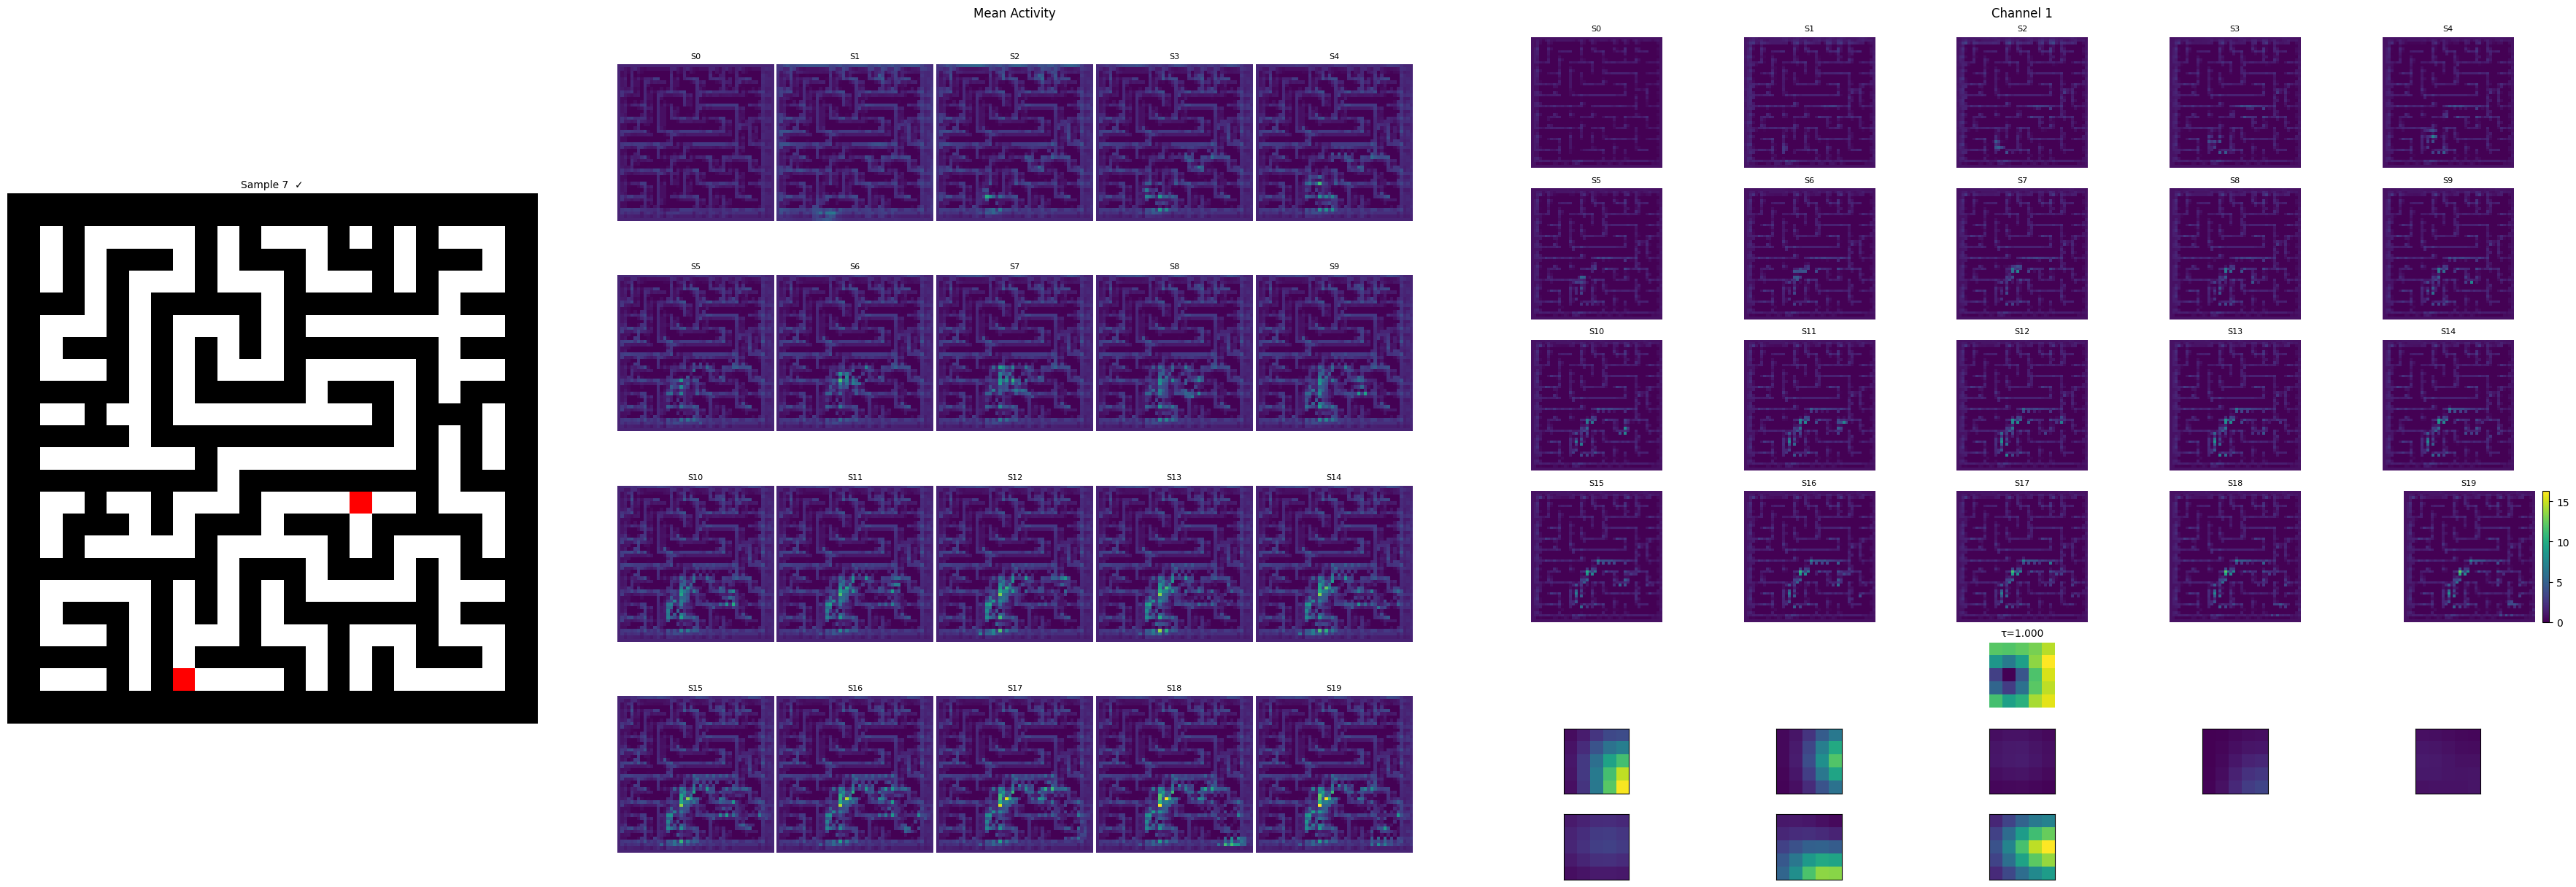

In [117]:
# ——— User‐set paths & names ———
wandb_name    = "twilight-spaceship-341"
checkpoint    = 390    # also used as epoch

# wandb_name = "happy-microwave-331"
# checkpoint = 200


def load_model_and_config(wandb_name, checkpoint_path):
    """Load model configuration and instantiate models."""
    try:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
    except:
        model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        num_steps = 20

    model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
    classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    mazes = Mazes(maze_data_path)
    
    return model, classifier, mazes, num_steps


def extract_weights(state_dict, excitatory, output):
    """Extract weight matrices and tau constants from state dict."""
    if excitatory:
        conv0 = state_dict["rnn.areas.0.convs.0->0.0.weight"].detach().cpu().numpy()
        e2e = state_dict["rnn.areas.0.convs.1->0.0.weight"].detach().cpu().numpy()
        taus = state_dict["rnn.areas.0.tau.0"].detach().cpu().numpy()[0, :, 0, 0]
    else:
        if output:
            e2e = state_dict["rnn.areas.0.convs.2->0.0.weight"].detach().cpu().numpy()
        else:
            e2e = state_dict["rnn.areas.0.convs.1->1.0.weight"].detach().cpu().numpy()
        conv0 = state_dict["rnn.areas.0.convs.0->1.0.weight"].detach().cpu().numpy()
        taus = state_dict["rnn.areas.0.tau.1"].detach().cpu().numpy()[0, :, 0, 0]
    
    return conv0, e2e, taus


def apply_gaussian_filter(data, sigma):
    """Apply Gaussian filter to data and return filtered data with min/max values."""
    filtered_data = gaussian_filter(data, sigma=sigma)
    return filtered_data, filtered_data.min(), filtered_data.max()


def create_activity_subplot(fig, subplot_spec, data, step, title, vmin=None, vmax=None, cmap='viridis'):
    """Create a standardized activity subplot."""
    ax = fig.add_subplot(subplot_spec)
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.axis('off')
    ax.set_title(title, fontsize=8)
    return ax, im


def highlight_self_kernel(ax, is_self=False):
    """Highlight the 'self' kernel with red border or hide borders for others."""
    if is_self:
        for side in ax.spines:
            spine = ax.spines[side]
            spine.set_visible(True)
            spine.set_edgecolor('red')
            spine.set_linewidth(1.5)
    else:
        for spine in ax.spines.values():
            spine.set_visible(False)


def plot_maze_sample(fig, outer_grid, row_idx, maze_data, sample_idx, is_correct):
    """Plot maze sample with correctness indicator."""
    ax = fig.add_subplot(outer_grid[row_idx, 0])
    ax.imshow(maze_data)
    ax.set_title(f"Sample {sample_idx} {' ✓' if is_correct else ' ✗'}", fontsize=10)
    ax.axis("off")


def plot_mean_activity_grid(fig, outer_grid, row_idx, col_idx, mean_activity, step_indices, n, m):
    """Plot mean activity across all channels in a grid layout."""
    mean_sub = outer_grid[row_idx, col_idx].subgridspec(
        n, m, height_ratios=[1]*n, hspace=0, wspace=0.02
    )
    
    mean_vmin, mean_vmax = mean_activity.min(), mean_activity.max()
    mean_ims, mean_axs = [], []
    
    for k, step in enumerate(step_indices):
        r, c = divmod(k, m)
        ax, im = create_activity_subplot(
            fig, mean_sub[r, c], mean_activity[step], 
            step, f"S{step}", mean_vmin, mean_vmax
        )
        mean_ims.append(im)
        mean_axs.append(ax)
    
    # Add column title
    ax_title = fig.add_subplot(outer_grid[0, col_idx])
    ax_title.axis('off')
    ax_title.set_title("Mean Activity", fontsize=12, pad=20)
    
    return mean_ims, mean_axs


def plot_channel_activity(fig, outer_grid, row_idx, col_idx, activity, channel_idx, 
                         step_indices, n, m, input_filter, tau, kernels, sigma_filter):
    """Plot activity for a single channel including activity panels, input filter, and kernels."""
    # Setup subgrid for this channel
    K = kernels.shape[0]
    kern_cols = m
    kern_rows = math.ceil(K / kern_cols)
    total_rows = n + 1 + kern_rows
    
    sub = outer_grid[row_idx, col_idx].subgridspec(
        total_rows, m,
        height_ratios=[1]*n + [0.5] + [0.5]*kern_rows,
        hspace=0.2, wspace=0.02
    )
    
    # Activity panels
    vmin, vmax = activity.flatten().min(), activity.flatten().max()
    ims, axs = [], []
    
    for k, step in enumerate(step_indices):
        r, c = divmod(k, m)
        ax, im = create_activity_subplot(
            fig, sub[r, c], activity[step, channel_idx], 
            step, f"S{step}", vmin, vmax
        )
        ims.append(im)
        axs.append(ax)
    
    # Add colorbar for activity panels
    if axs:
        plt.colorbar(ims[-1], ax=axs[-1], fraction=0.046, pad=0.04)
    
    # Column title
    ax_title = fig.add_subplot(outer_grid[0, col_idx])
    ax_title.axis('off')
    ax_title.set_title(f"Channel {channel_idx}", fontsize=12, pad=20)
    
    # Input filter
    filtered_filter, wf_vmin, wf_vmax = apply_gaussian_filter(input_filter, sigma_filter)
    ax_filter = fig.add_subplot(sub[n, :])
    im_filter = ax_filter.imshow(filtered_filter, cmap='viridis', vmin=wf_vmin, vmax=wf_vmax)
    ax_filter.set_title(f"τ={tau:.3f}", fontsize=10)
    ax_filter.axis('off')
    
    # e→e kernels
    filtered_kernels = [gaussian_filter(kernel, sigma=sigma_filter) for kernel in kernels]
    wvmin, wvmax = min(k.min() for k in filtered_kernels), max(k.max() for k in filtered_kernels)
    
    kernel_ims, kernel_axs = [], []
    for k, kernel in enumerate(filtered_kernels):
        rr = n + 1 + (k // kern_cols)
        cc = k % kern_cols
        ax_kernel = fig.add_subplot(sub[rr, cc])
        im_kernel = ax_kernel.imshow(kernel, cmap='viridis', vmin=wvmin, vmax=wvmax)
        ax_kernel.set_xticks([])
        ax_kernel.set_yticks([])
        
        # Highlight self kernel
        if do_highlight_self_kernel:
            highlight_self_kernel(ax_kernel, k == channel_idx)
        
        kernel_ims.append(im_kernel)
        kernel_axs.append(ax_kernel)
    
    return ims, axs, kernel_ims, kernel_axs


# ——— Load model config & instantiate ———
model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)

# ——— Load checkpoint & weights ———
state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
model.load_state_dict(prepare_rnn_weights(state_dict))
classifier.load_state_dict(state_dict)

# ——— Plot settings ———
excitatory = False
input_channel = 0 # 0 is walls, -1 is starting points
plot_maze = True
n, m = 4, 5  # activity grid dims
sigma_filter = 1.0  # optional blur for weights
output = True  # if True: kernels = e2e[:, j], else: kernels = e2e[j, :]
channels_to_plot = [1]  # None plots all channels, or specify list like [0, 2, 5] for specific channels
samples_to_plot = [7]  # None plots all samples, or specify list like [0, 2, 5] for specific samples
do_highlight_self_kernel = False

# ——— Extract weight‐matrices & taus ———
conv0, e2e, taus = extract_weights(state_dict, excitatory, output)
input_filters = conv0[:, input_channel]  # ⇒ (C, H, W)

# Precompute channel count and filter channels if specified
C = input_filters.shape[0]
if channels_to_plot is not None:
    # Validate channel indices
    if not all(0 <= ch < C for ch in channels_to_plot):
        raise ValueError(f"Channel indices must be between 0 and {C-1}")
    channel_indices = channels_to_plot
    C_plot = len(channel_indices)
else:
    channel_indices = list(range(C))
    C_plot = C

# Number of columns for activity: one per channel (+1 for maze)
num_cols = C_plot + 1 + (1 if plot_maze else 0)

# Filter samples if specified
if samples_to_plot is not None:
    # Validate sample indices
    if not all(0 <= s < len(inputs) for s in samples_to_plot):
        raise ValueError(f"Sample indices must be between 0 and {len(inputs)-1}")
    sample_indices = samples_to_plot
    num_inputs = len(sample_indices)
else:
    sample_indices = list(range(len(inputs)))
    num_inputs = len(inputs)

# Setup main figure
fig = plt.figure(figsize=(3 * num_cols * m, 15 * num_inputs))
# Calculate width ratios dynamically based on what we're plotting
if plot_maze:
    width_ratios = [1] + [1.5] + [2] * C_plot
else:
    width_ratios = [1.5] + [2] * C_plot

outer = fig.add_gridspec(
    num_inputs, num_cols,
    width_ratios=width_ratios,
    hspace=0.2, wspace=0.1
)

# Pre-filter kernels for consistent color scaling
full_wvmin, full_wvmax = np.inf, -np.inf
for j in channel_indices:
    kernels = e2e[:, j] if output else e2e[j, :]
    for k in range(len(kernels)):
        kernels[k] = gaussian_filter(kernels[k], sigma=sigma_filter)
    wvmin, wvmax = kernels.min(), kernels.max()
    full_wvmin = min(full_wvmin, wvmin)
    full_wvmax = max(full_wvmax, wvmax)

# Main plotting loop
for plot_idx, sample_idx in enumerate(sample_indices):
    inp, label = inputs[sample_idx], labels[sample_idx]
    # Compute activity for sample i
    out = classifier(inp.unsqueeze(0), num_steps=num_steps)
    correct = (out.argmax(dim=1).item() == label)

    _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps)
    act = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
               .detach().cpu()[0]  # shape (T, C)
    T = act.shape[0]
    step_idxs = np.linspace(0, T - 1, n * m, dtype=int)

    # Plot maze if desired
    col_offset = 0
    if plot_maze:
        plot_maze_sample(fig, outer, plot_idx, mazes.tensor_to_image(inp), sample_idx, correct)
        col_offset = 1
    
    # Compute and plot mean activity
    mean_act = torch.mean(act, dim=1)
    plot_mean_activity_grid(fig, outer, plot_idx, col_offset, mean_act, step_idxs, n, m)
    col_offset += 1

    # Plot each channel
    for channel_plot_idx, j in enumerate(channel_indices):
        col = channel_plot_idx + col_offset
        kernels = e2e[:, j] if output else e2e[j, :]
        
        plot_channel_activity(
            fig, outer, plot_idx, col, act, j, step_idxs, n, m,
            input_filters[j], taus[j], kernels, sigma_filter
        )

plt.tight_layout()
plt.show()

/tmp/ipykernel_2726475/2783782132.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locati

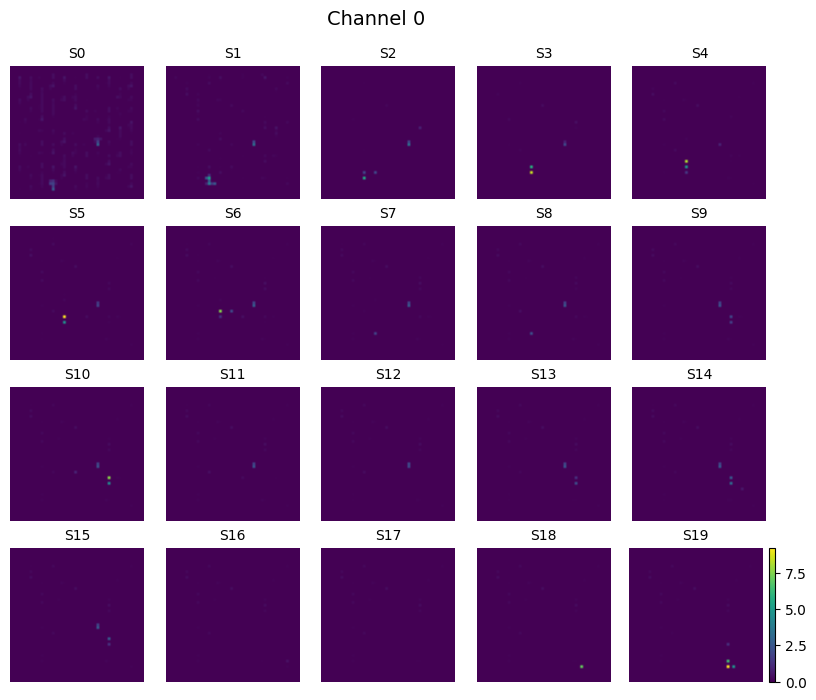

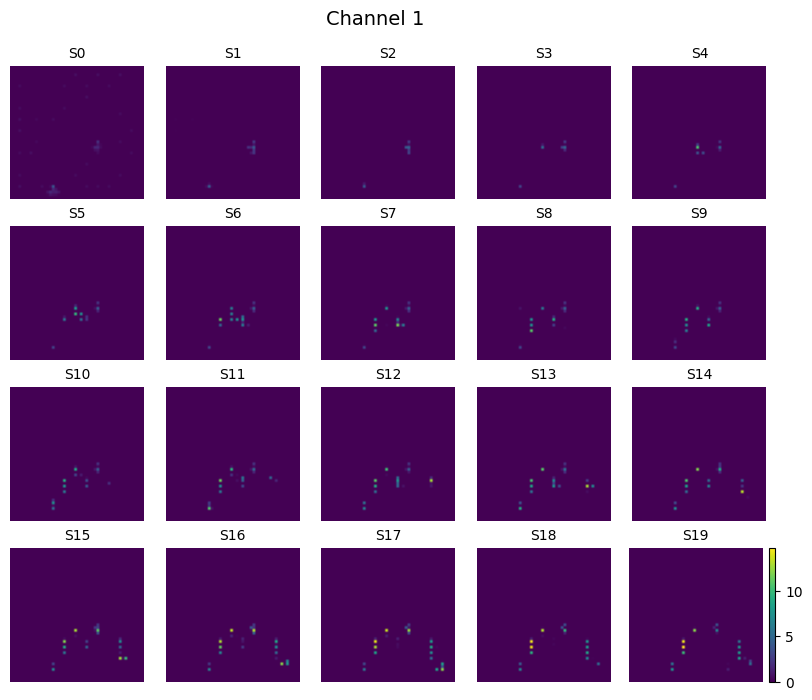

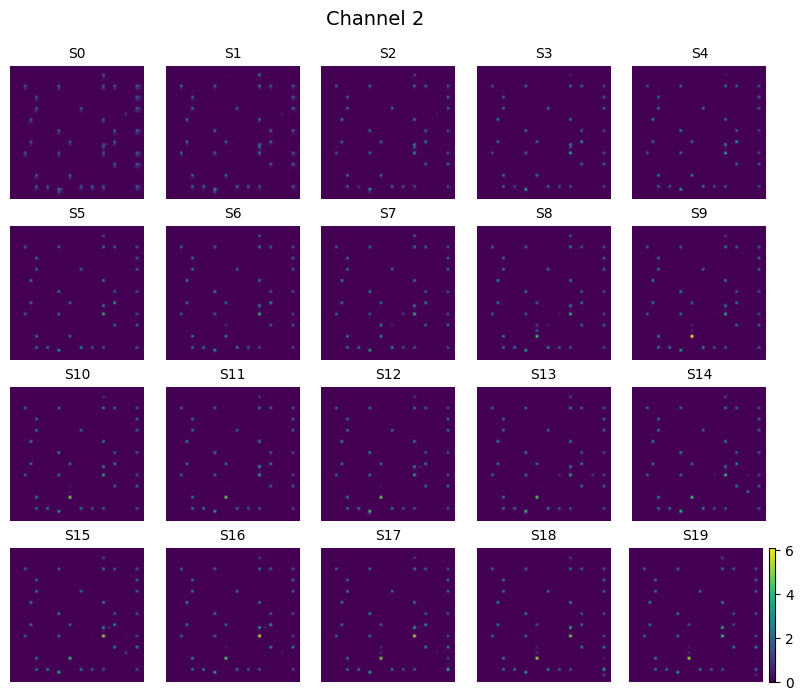

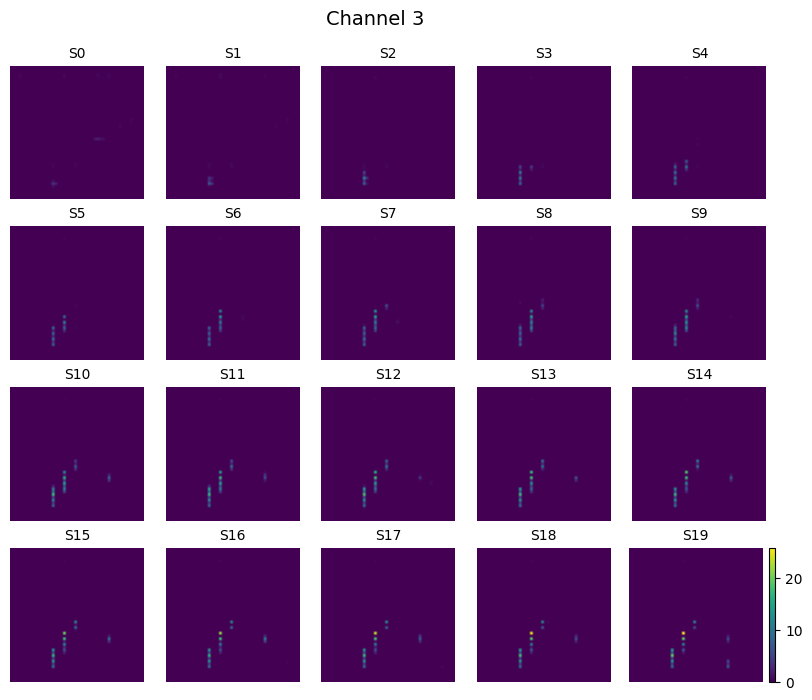

In [99]:
def plot_channel_activity_solo(
    activity,       # array of shape [T, C, H, W]
    channel_idx,    # which channel to plot
    n, m,           # grid layout: n rows, m cols
    cmap='viridis'  # optional colormap
):
    """
    Standalone plot of just the activity panels for one channel.
    """
    T = activity.shape[0]
    step_indices = np.linspace(0, T - 1, n * m, dtype=int)

    # compute shared color‐scale over all selected frames
    vmin = torch.min(activity[:, channel_idx])
    vmax = torch.max(activity[:, channel_idx])
    # make figure + gridspec
    fig = plt.figure(figsize=(m * 2, n * 2))
    grid = fig.add_gridspec(n, m, hspace=0.2, wspace=0.02)
    fig.suptitle(f"Channel {channel_idx}", fontsize=14, y=0.95)

    for idx, step in enumerate(step_indices):
        r, c = divmod(idx, m)
        ax = fig.add_subplot(grid[r, c])
        im = ax.imshow(activity[step, channel_idx], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"S{step}", fontsize=10)
        ax.axis('off')

        # only add colorbar on the last panel
        if idx == len(step_indices) - 1:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.show()

# ——— Load model config & instantiate ———
model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)

# ——— Load checkpoint & weights ———
state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
model.load_state_dict(prepare_rnn_weights(state_dict))

# ——— Plot settings ———
excitatory = True
n, m = 4, 5  # activity grid dims
sigma_filter = 1.0  # optional blur for weights
channels_to_plot = [0, 1, 2, 3] 
sample_indices = [7]
do_highlight_self_kernel = False

# Main plotting loop
for plot_idx, sample_idx in enumerate(sample_indices):
    inp, label = inputs[sample_idx], labels[sample_idx]
    _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps)
    activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
               .detach().cpu()[0]  # shape (T, C)

    for channel_idx in channels_to_plot:
        plot_channel_activity_solo(
                    activity, channel_idx, n, m)

/tmp/ipykernel_2726475/863841243.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locatio

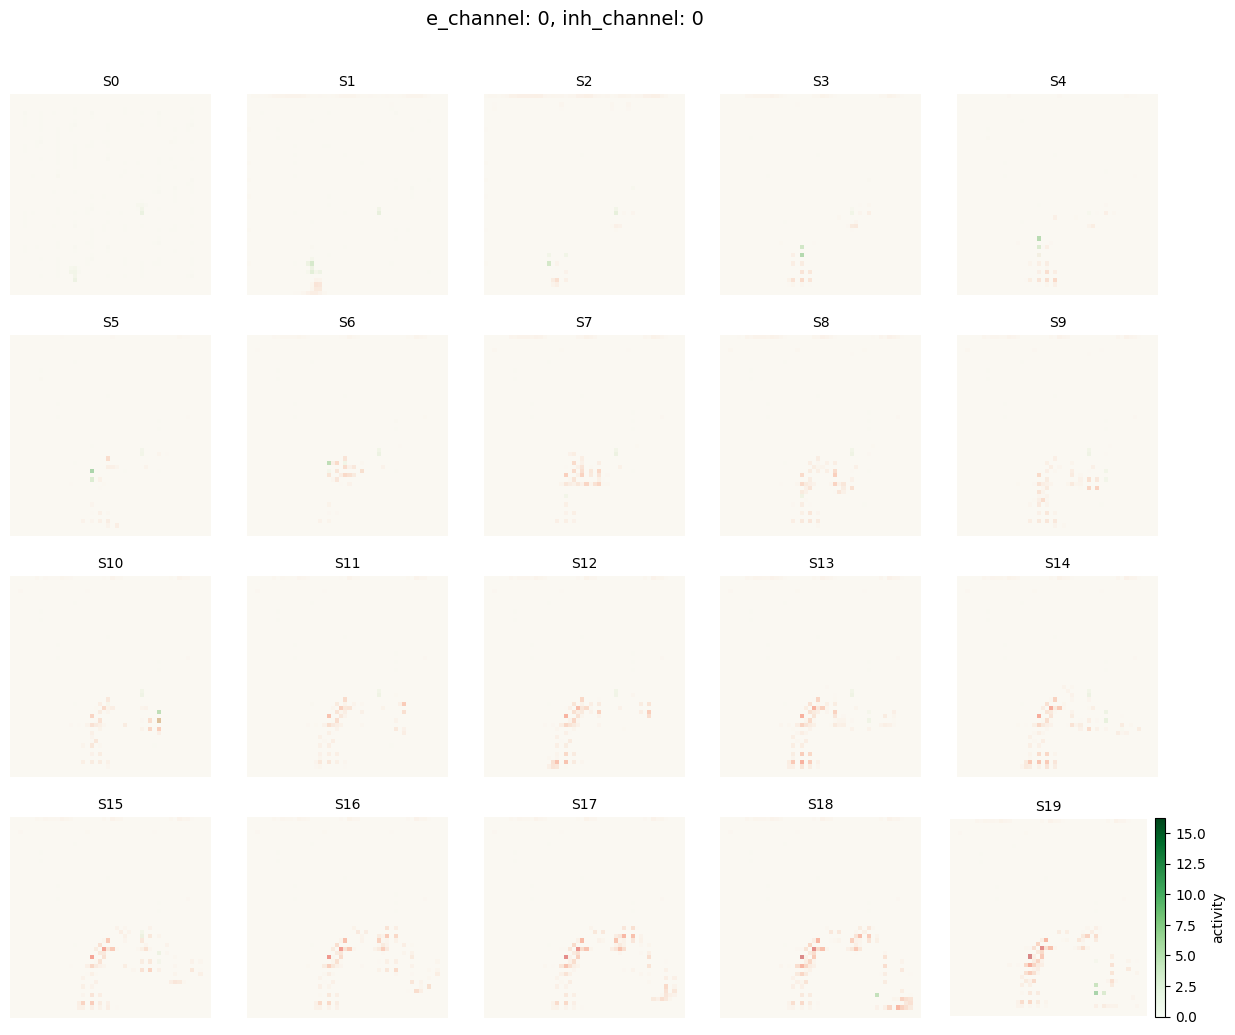

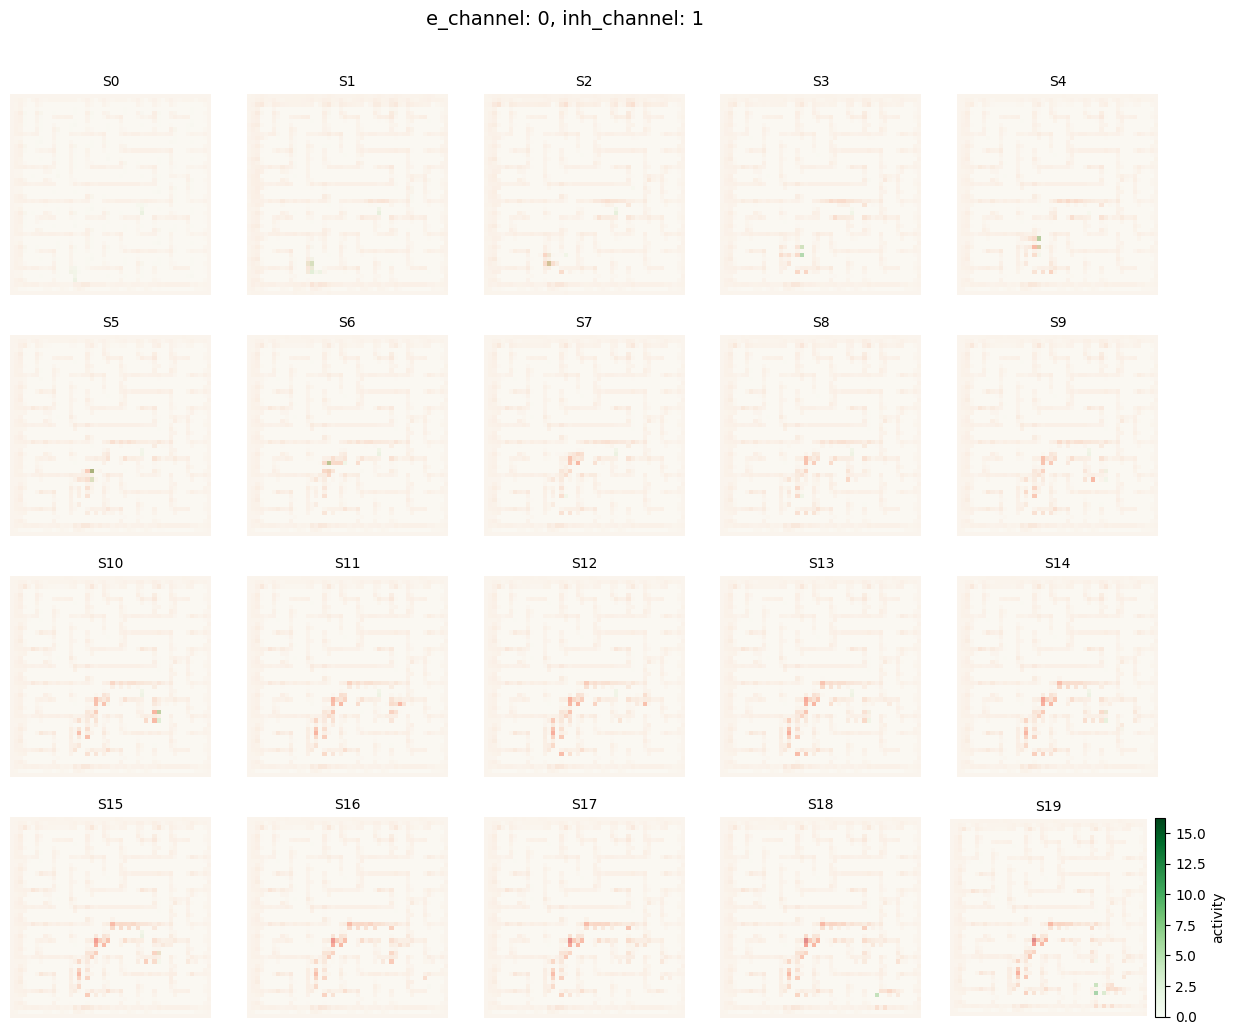

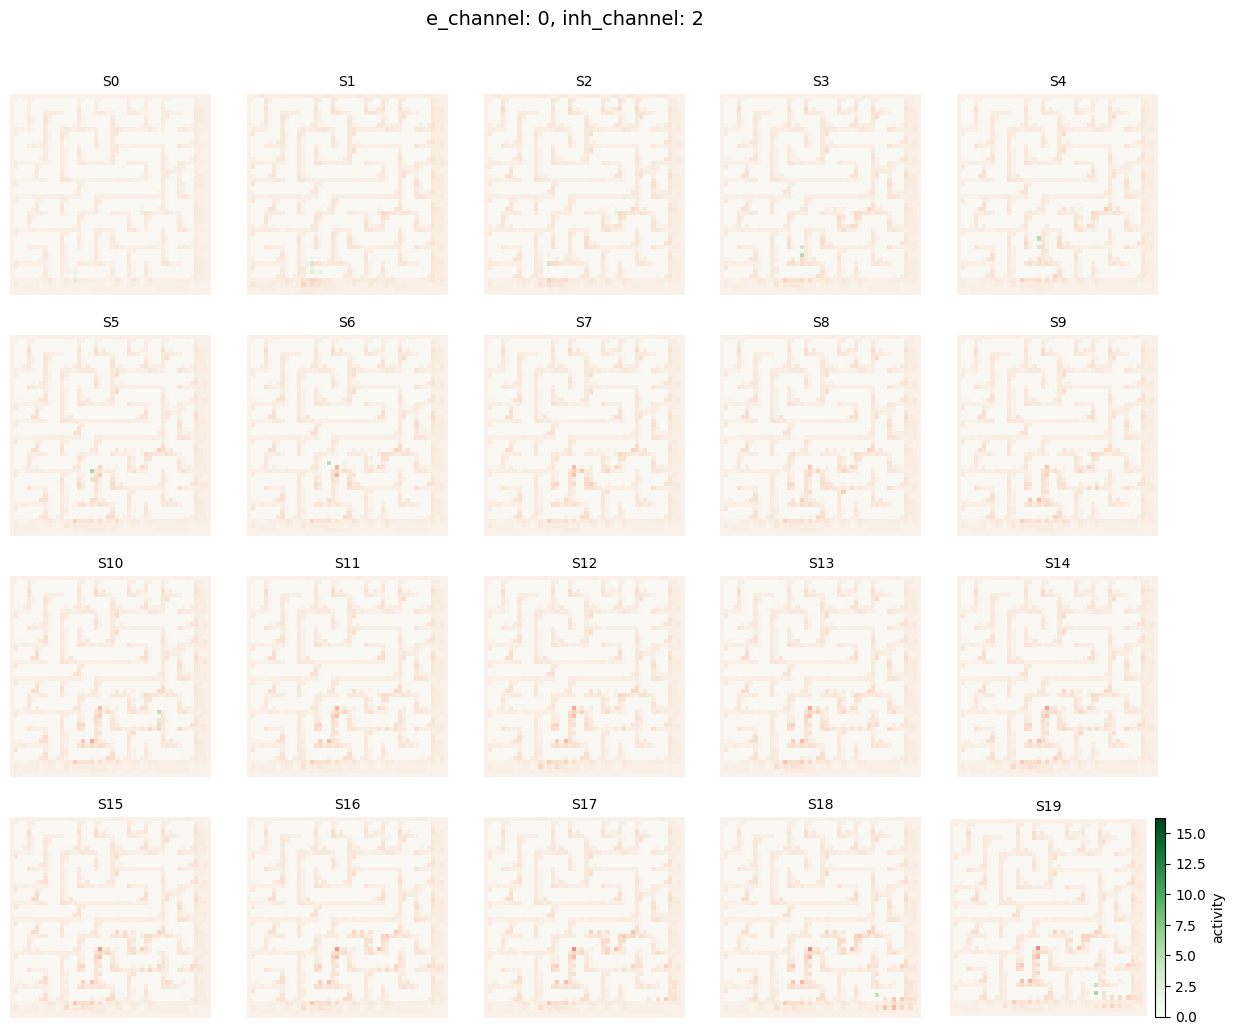

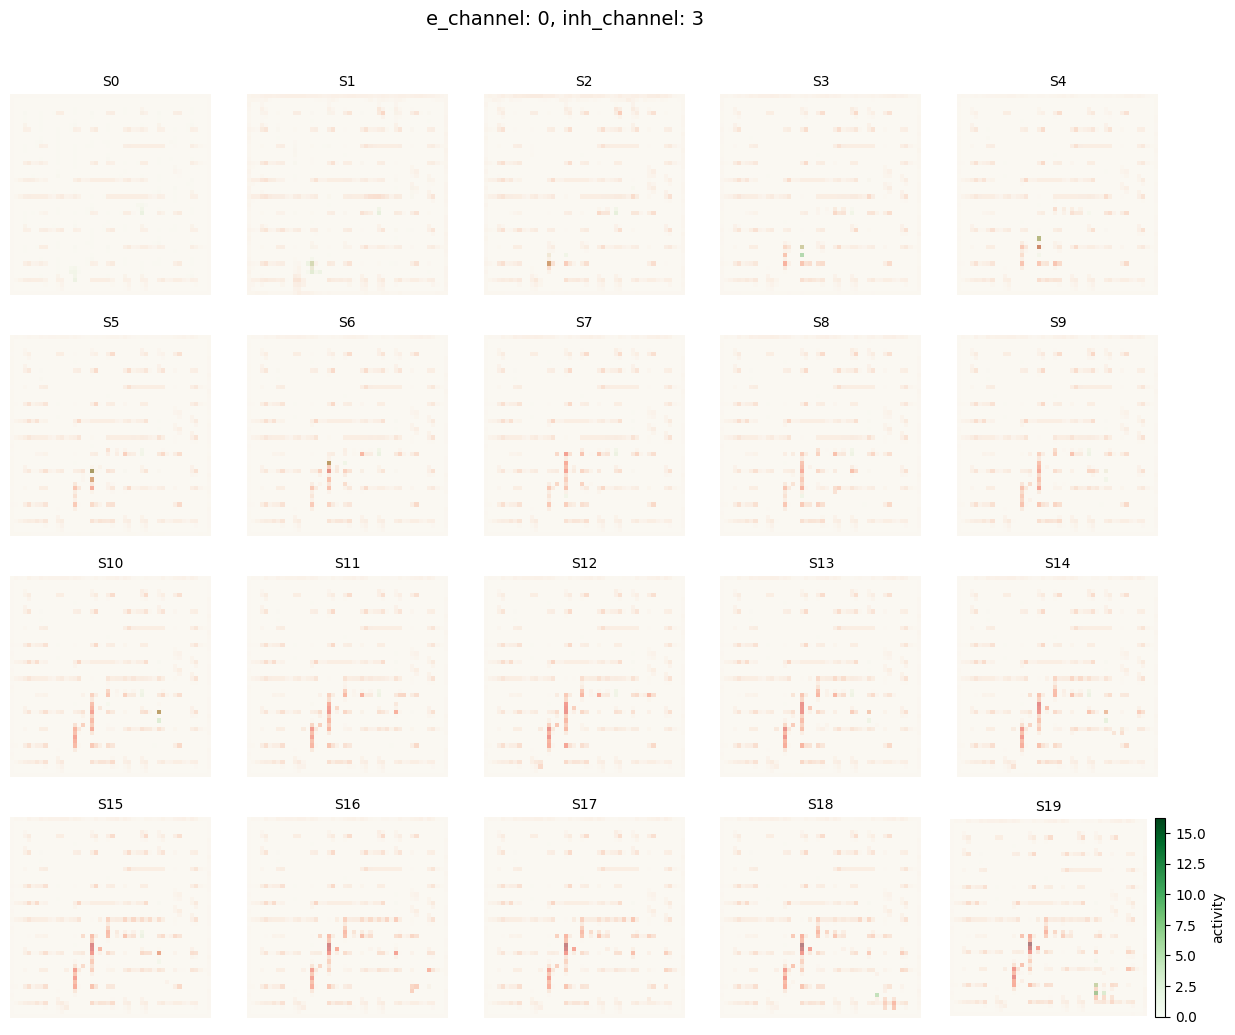

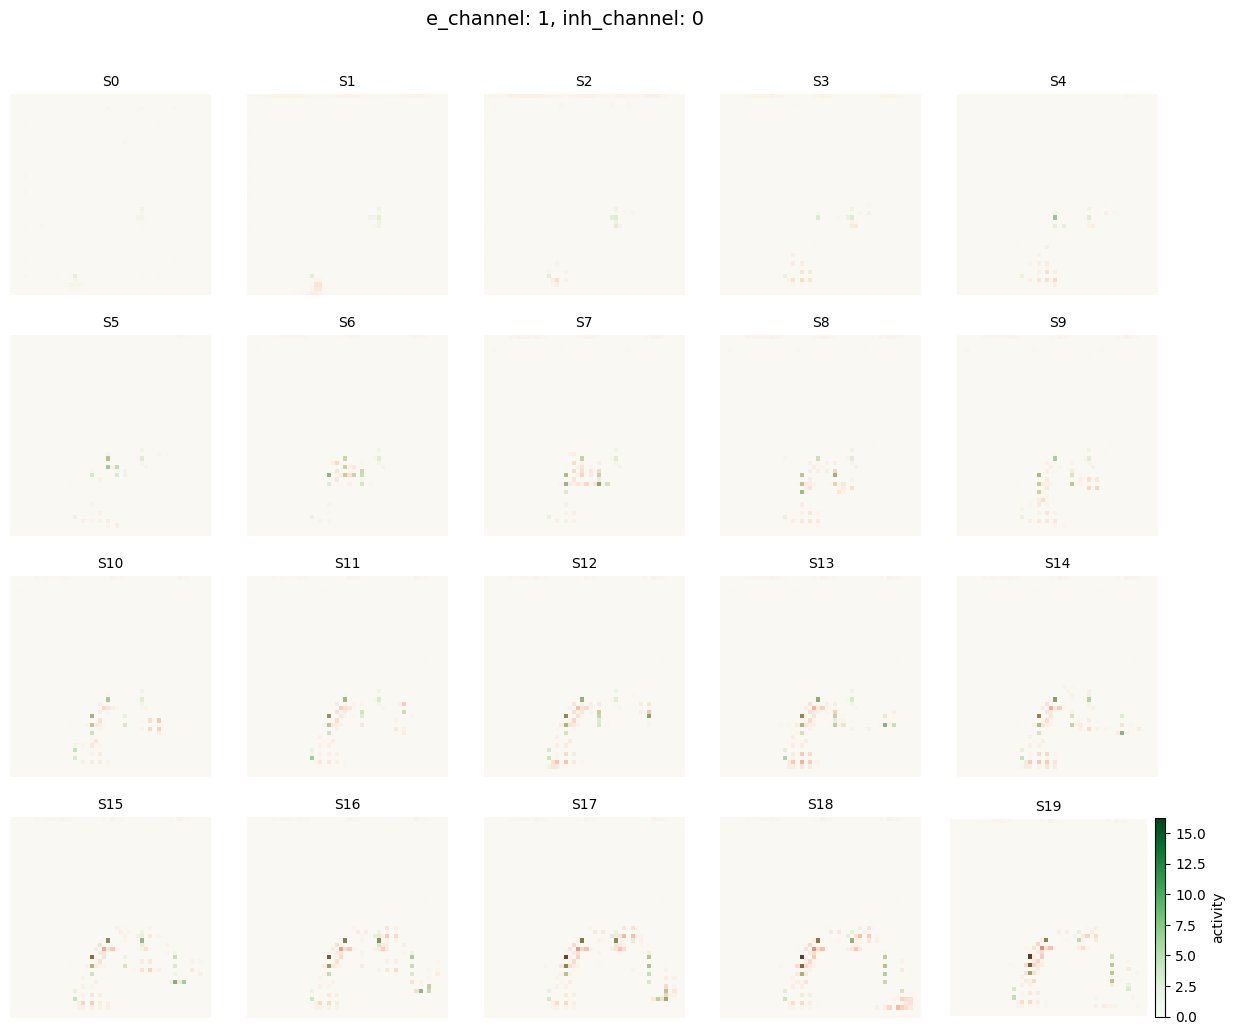

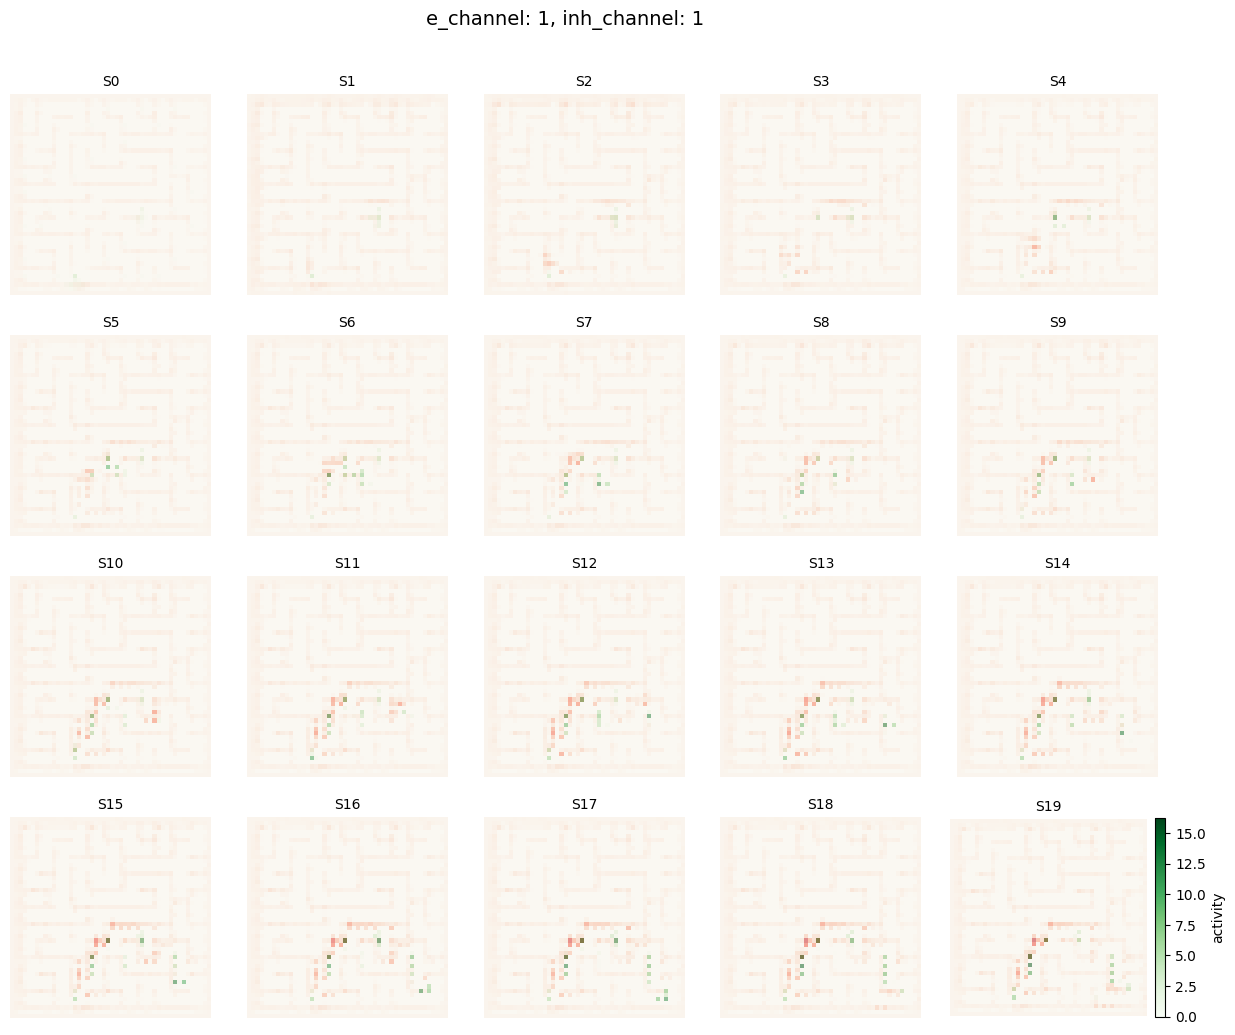

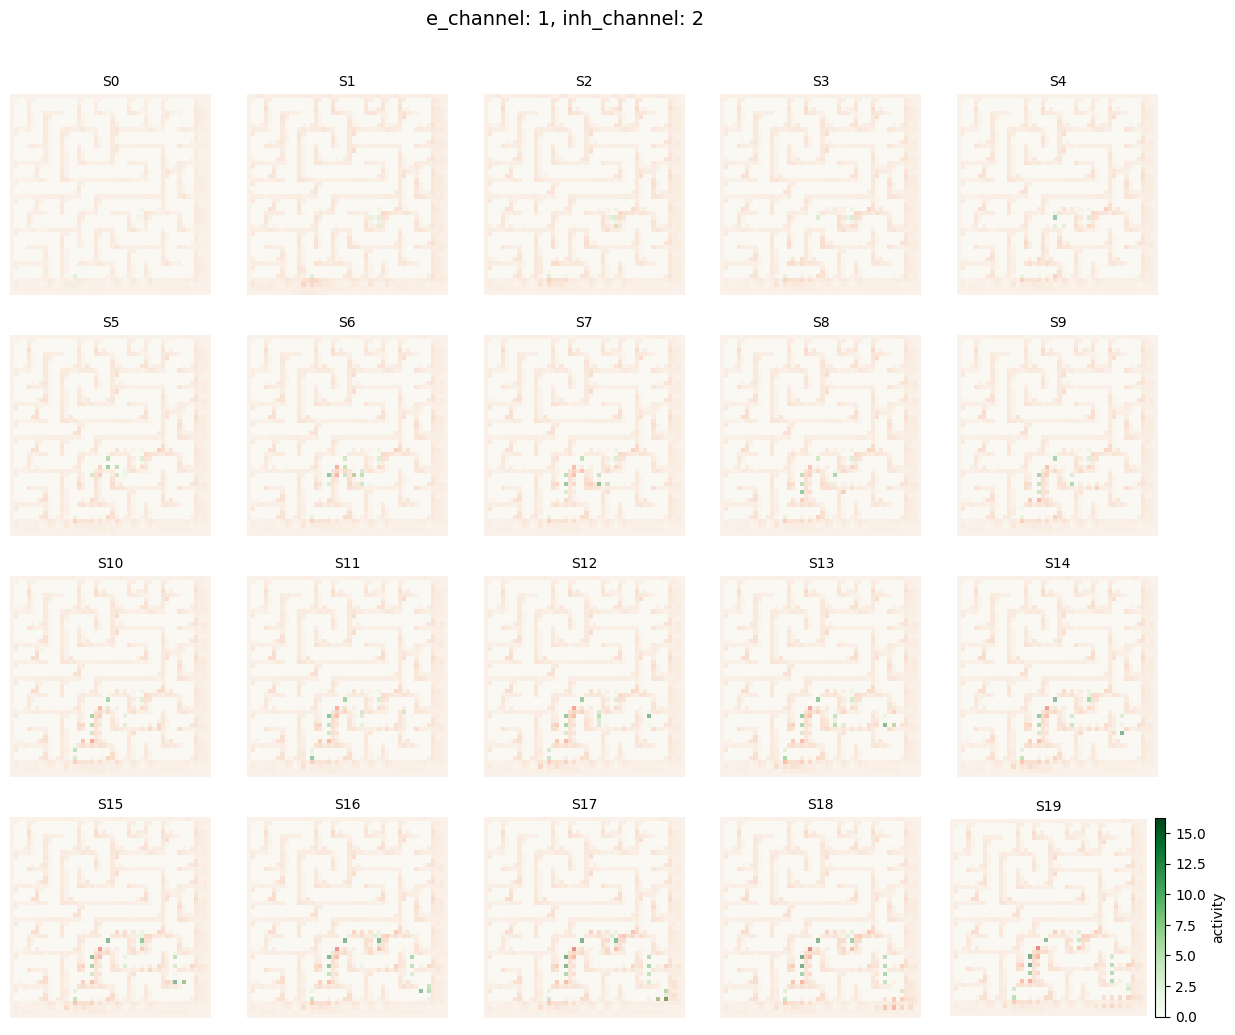

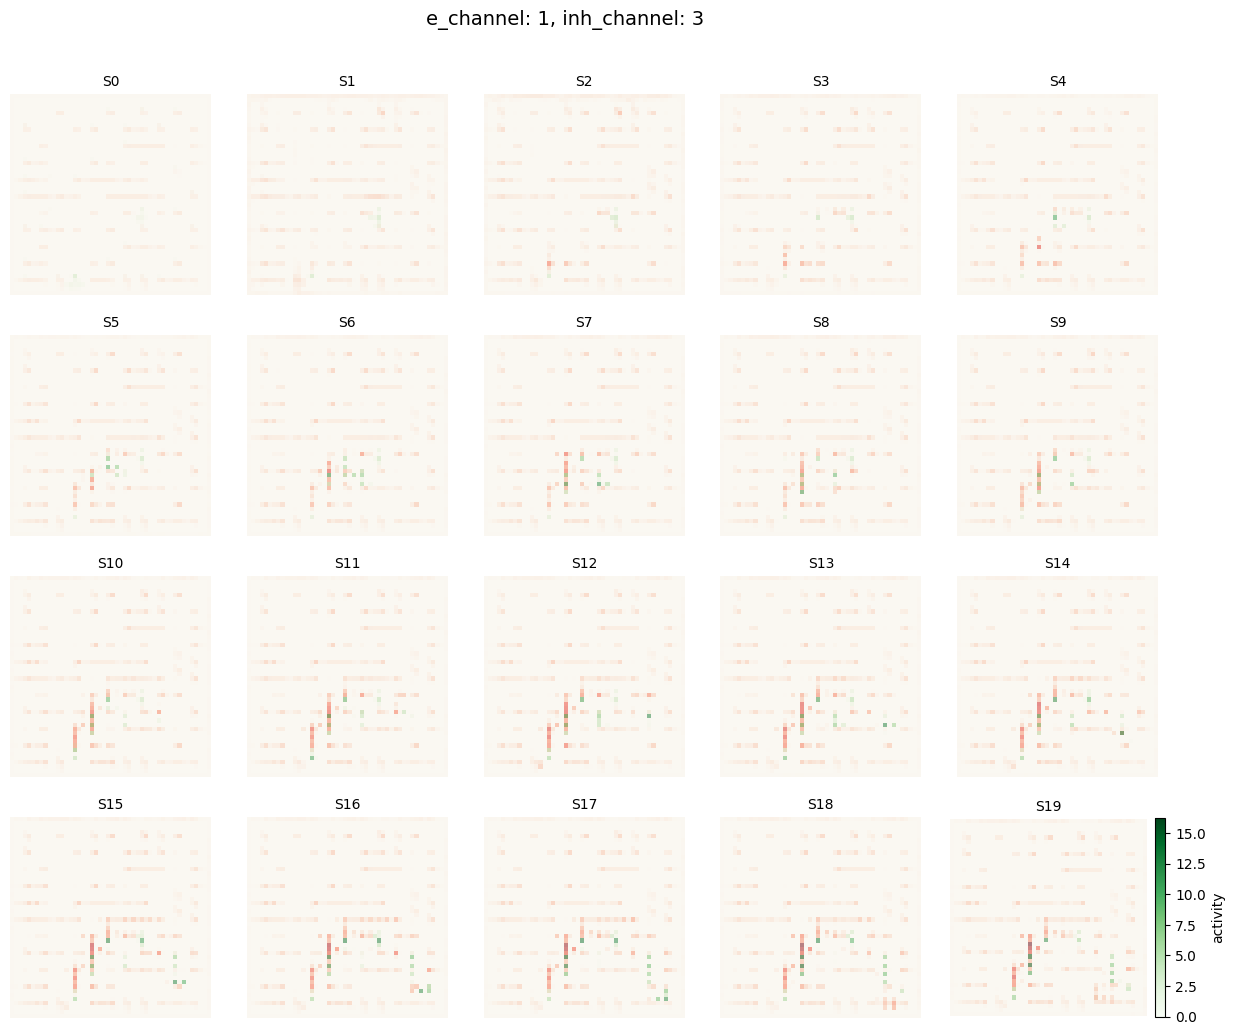

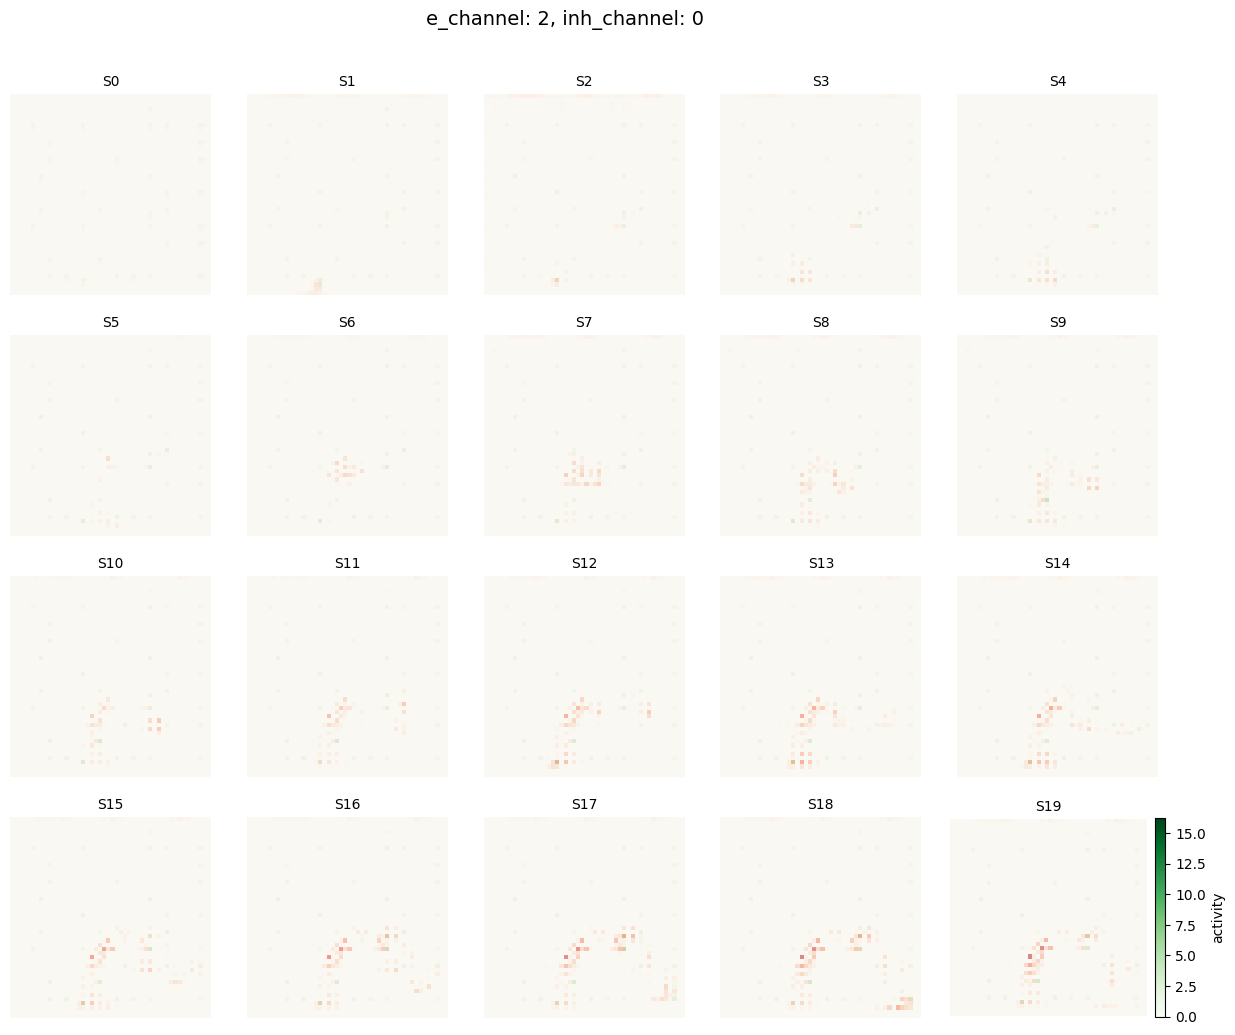

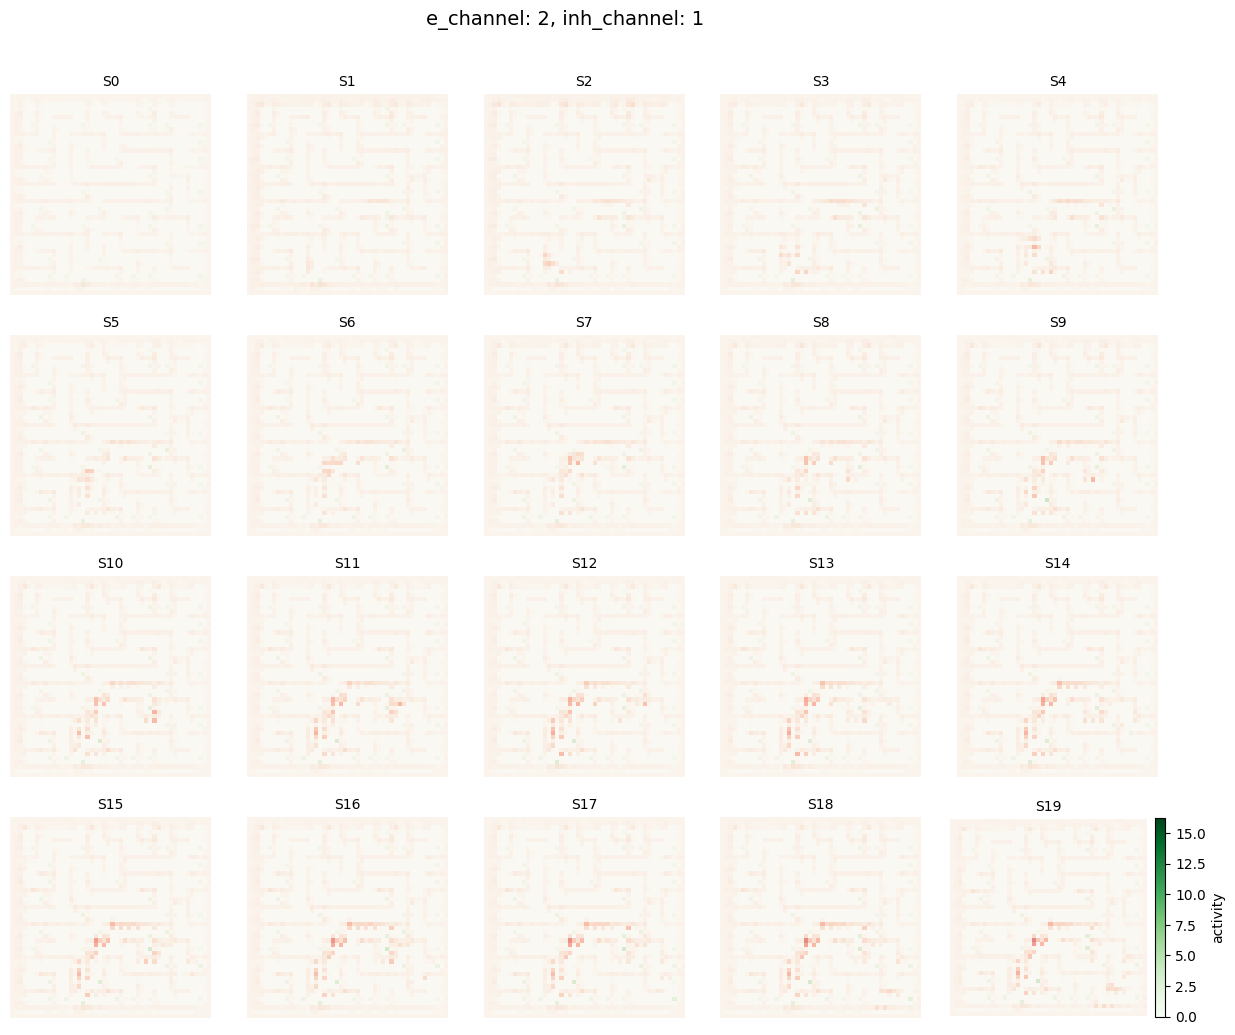

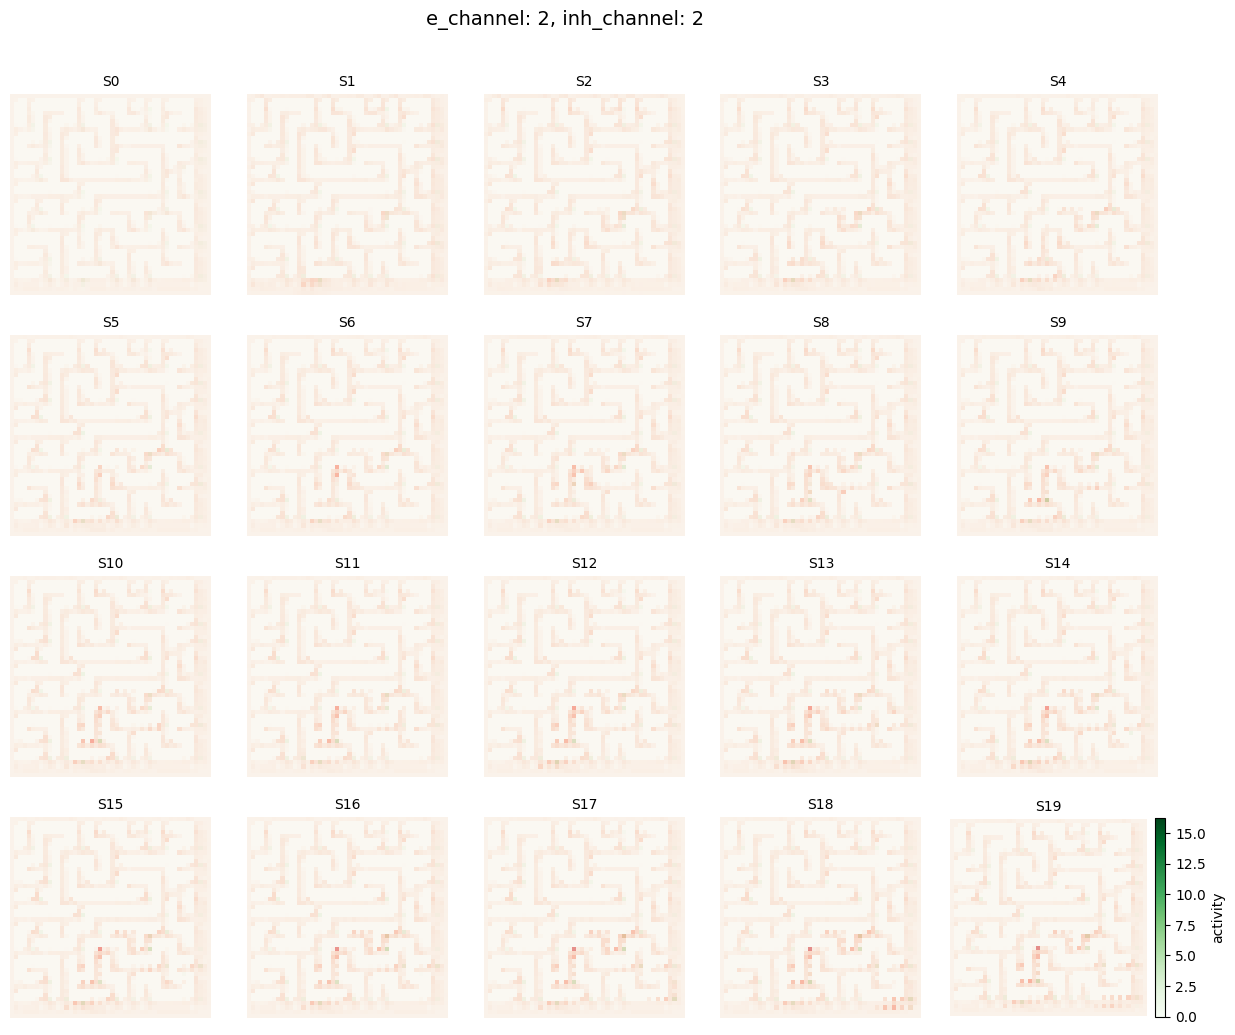

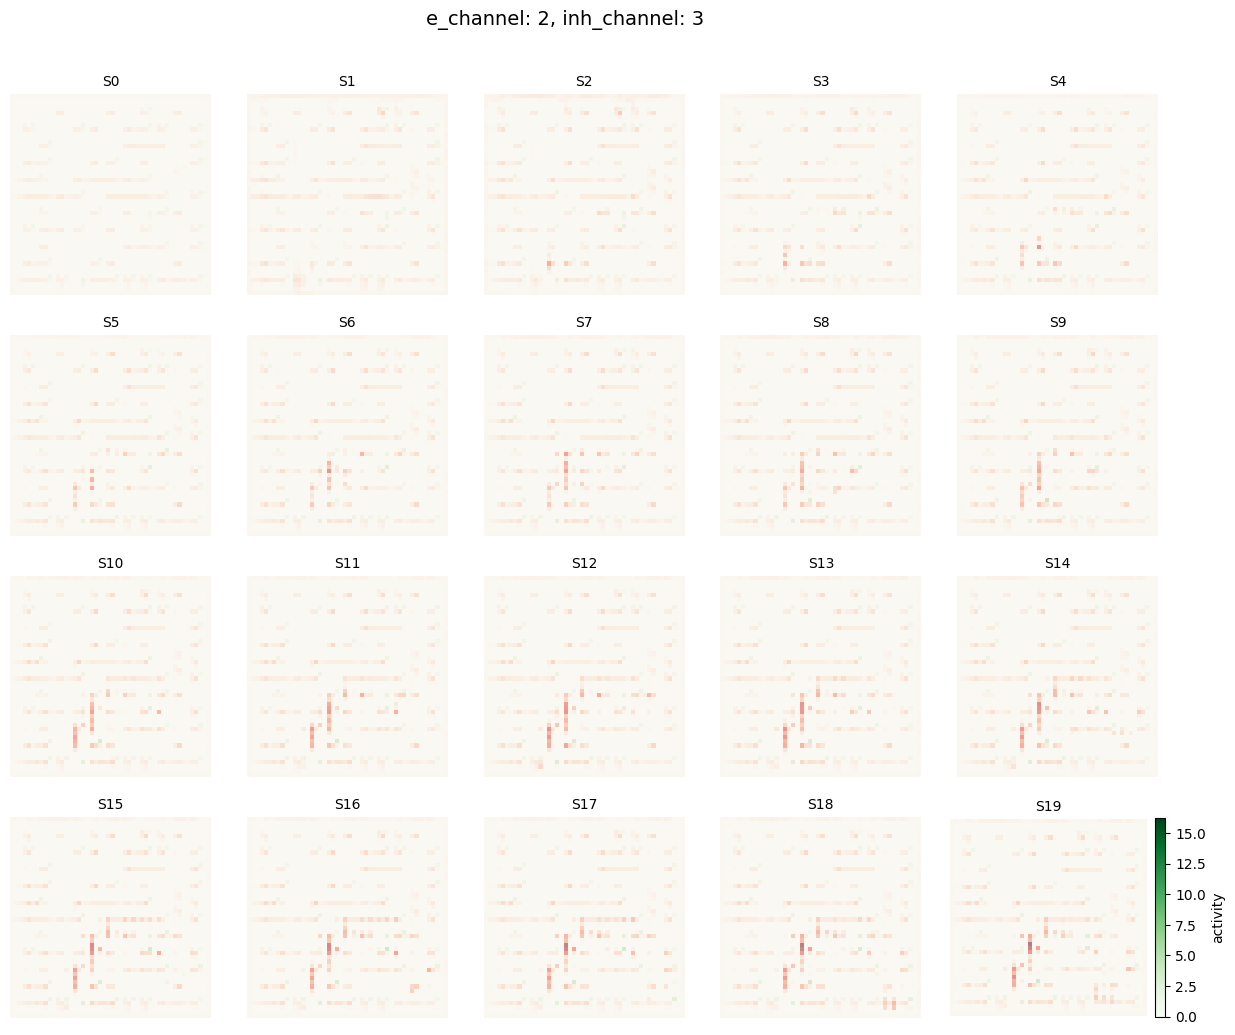

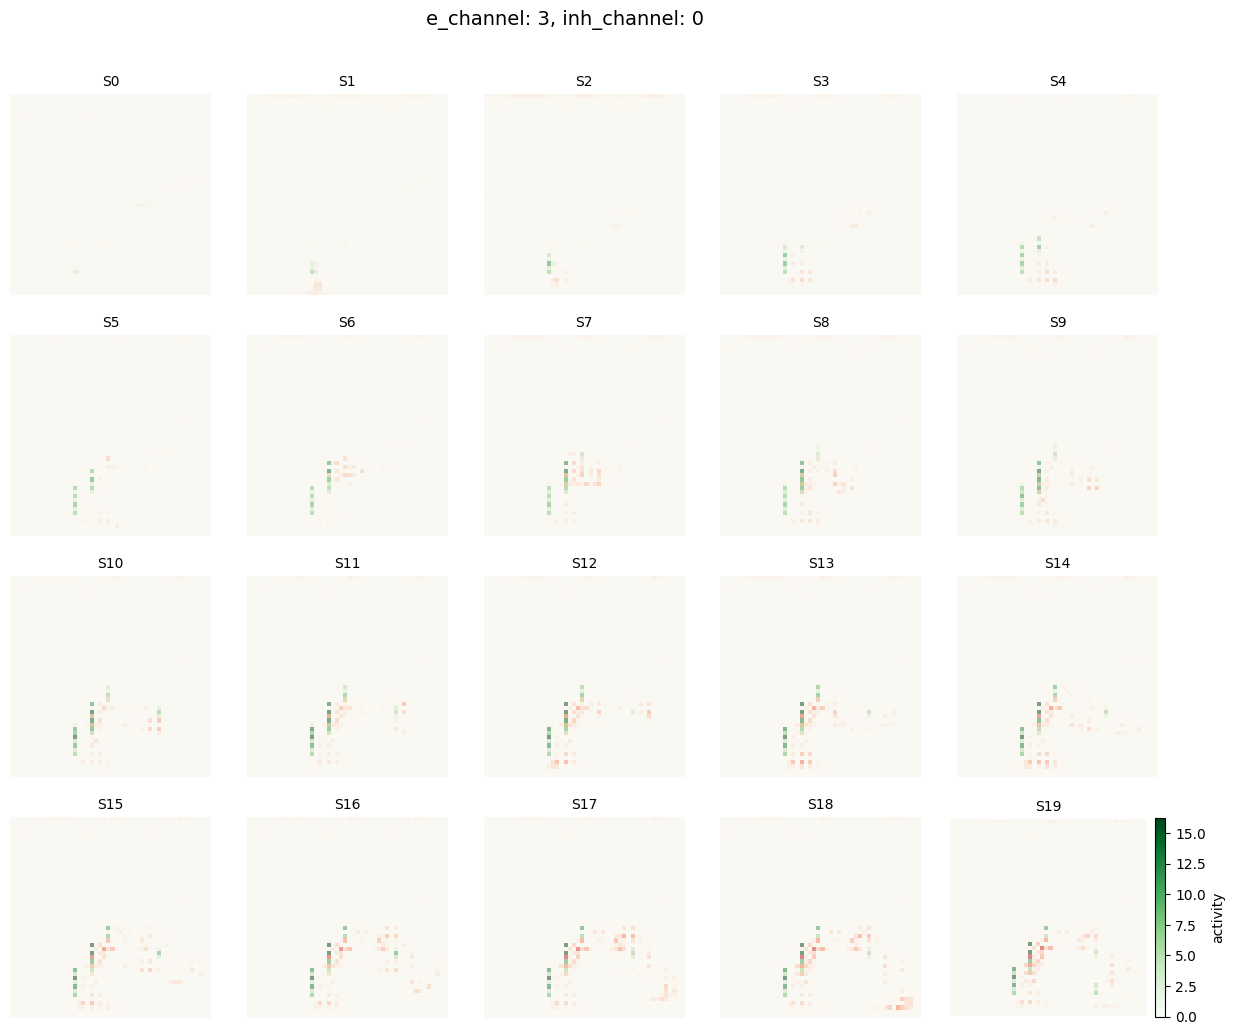

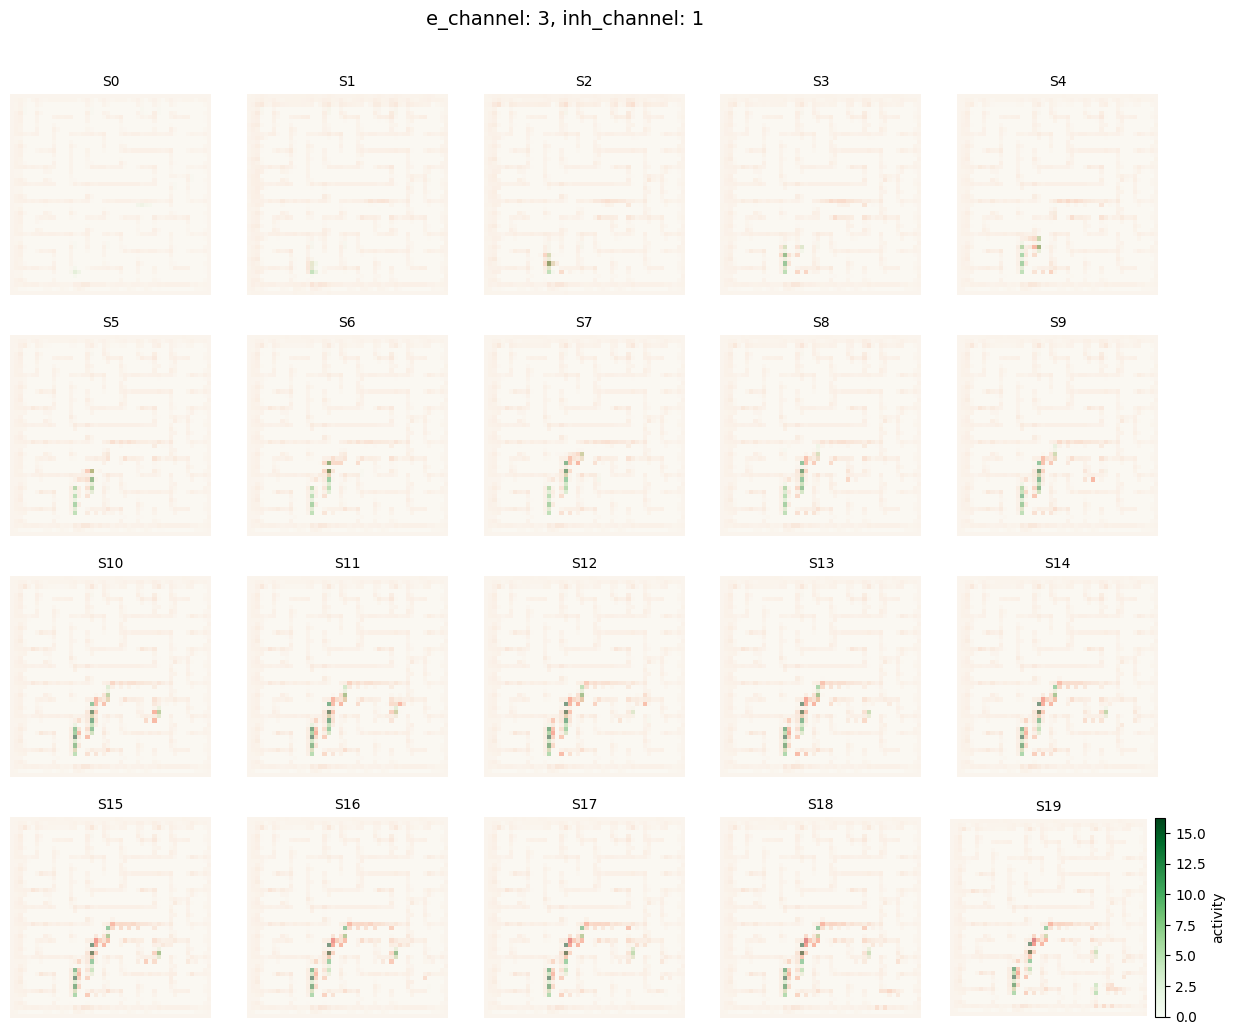

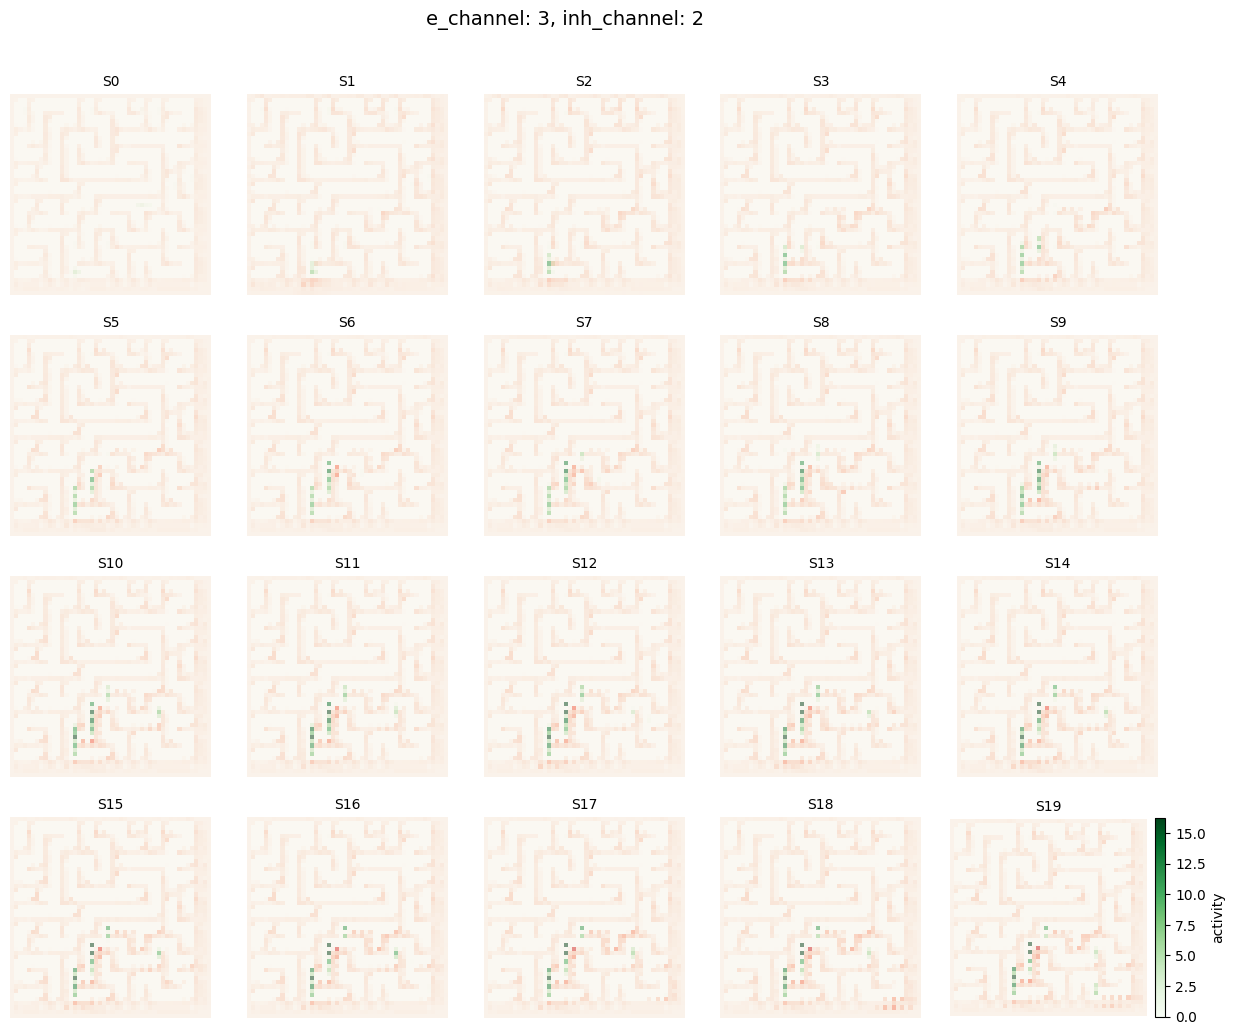

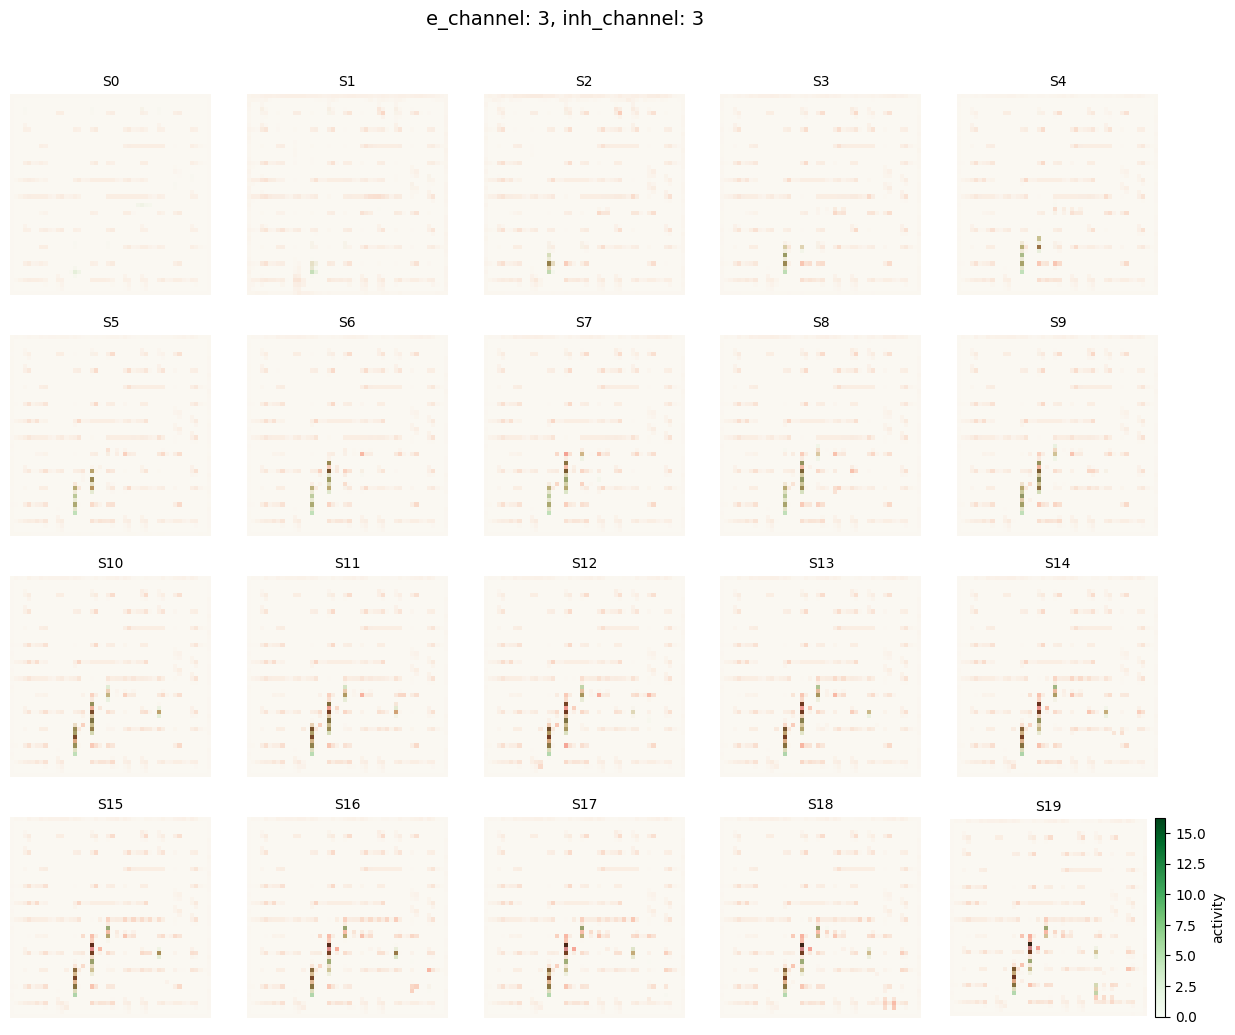

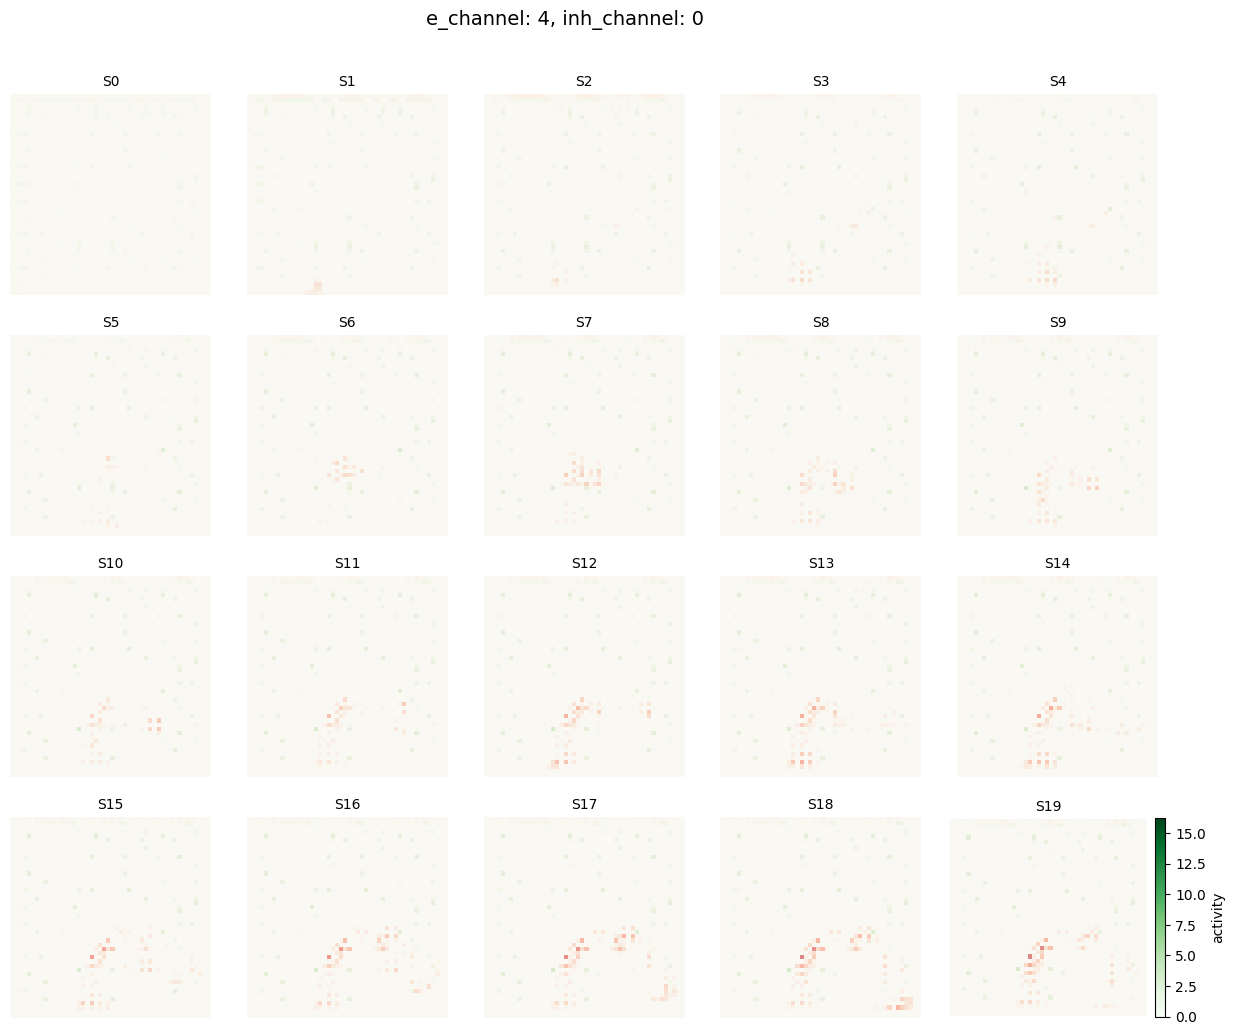

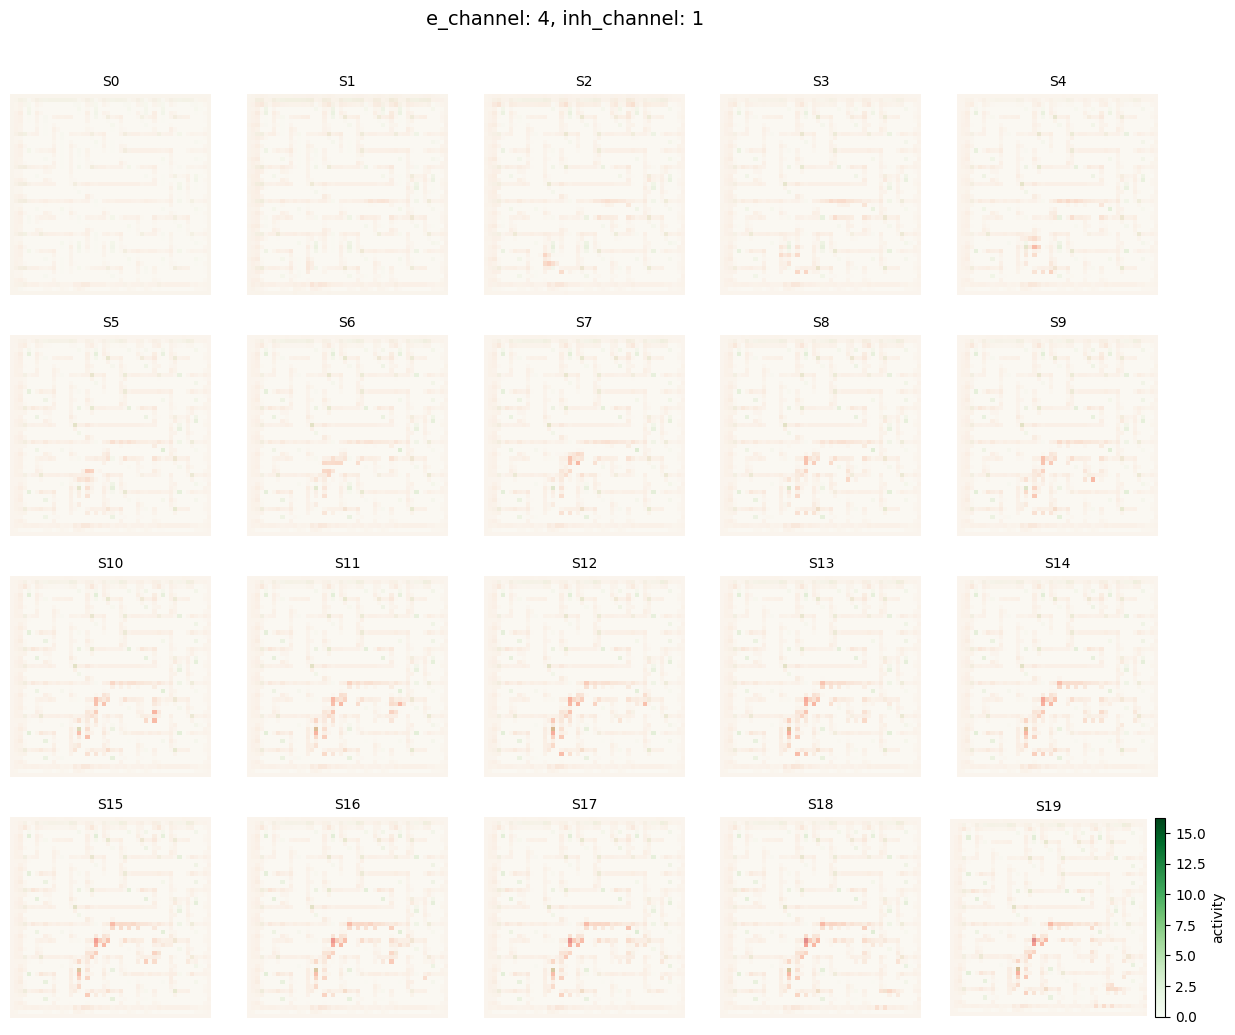

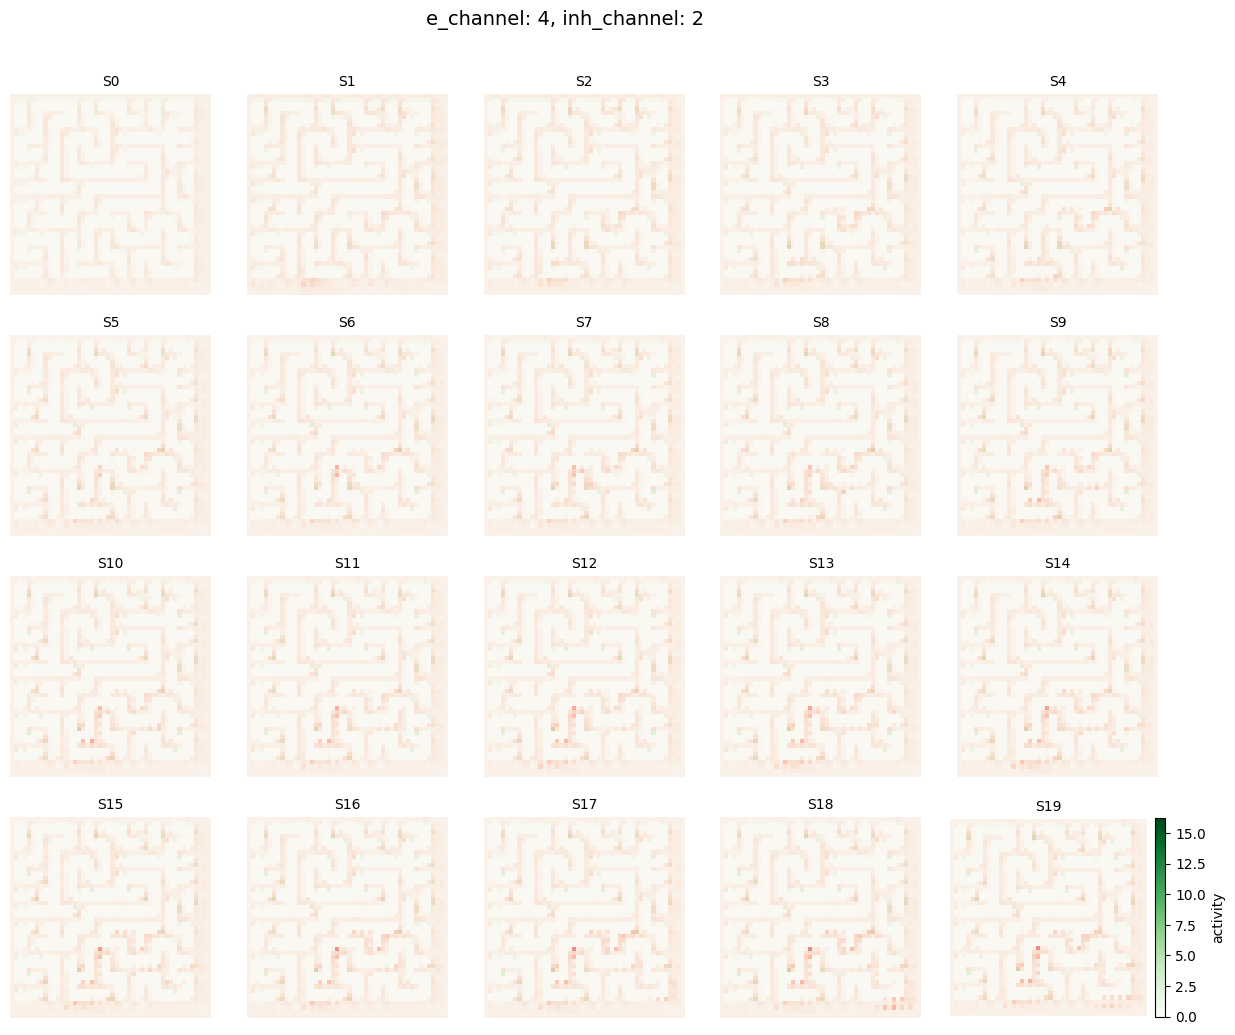

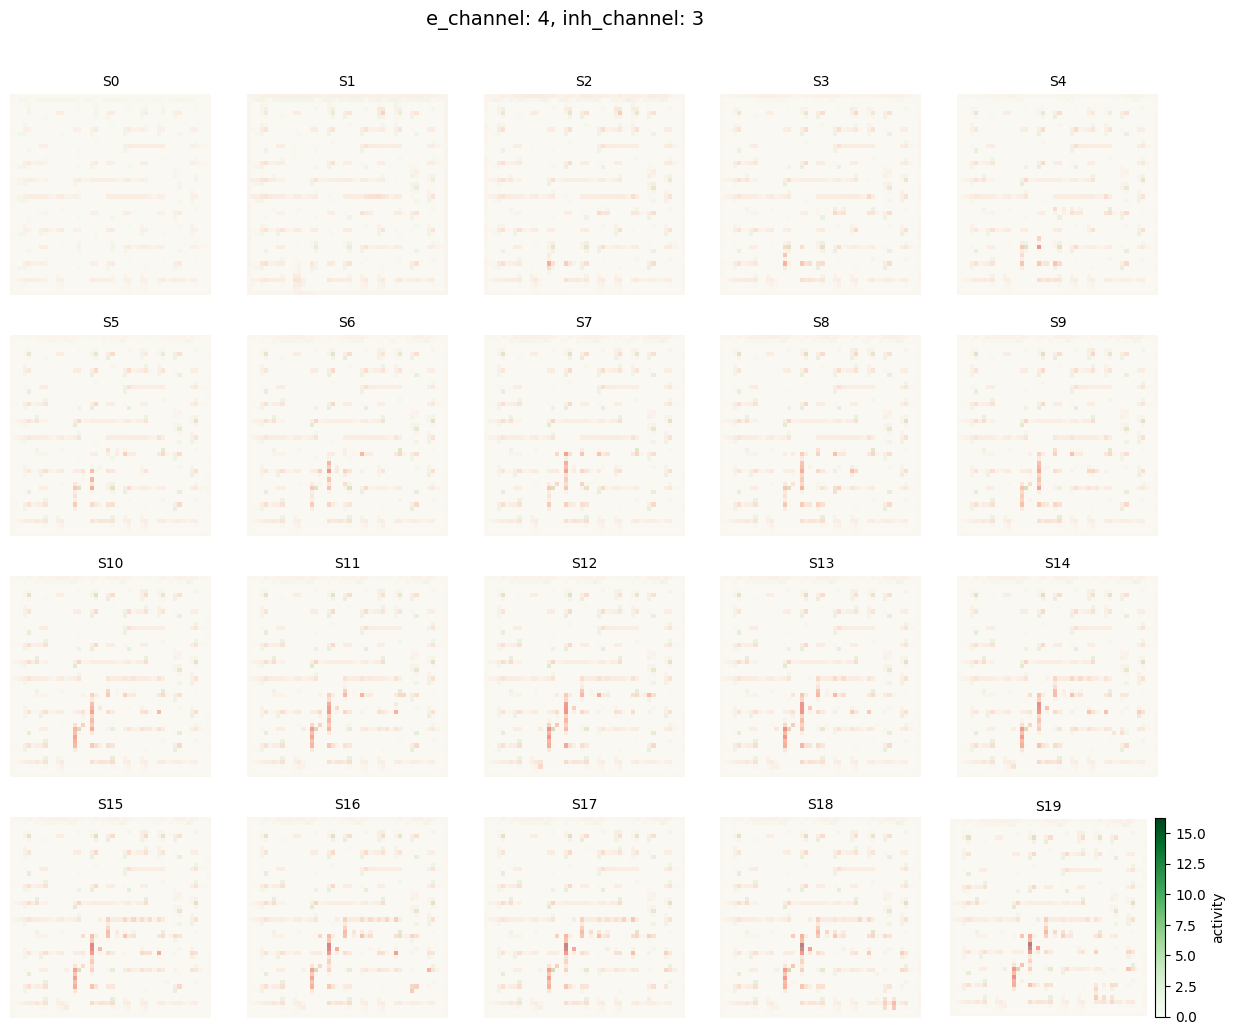

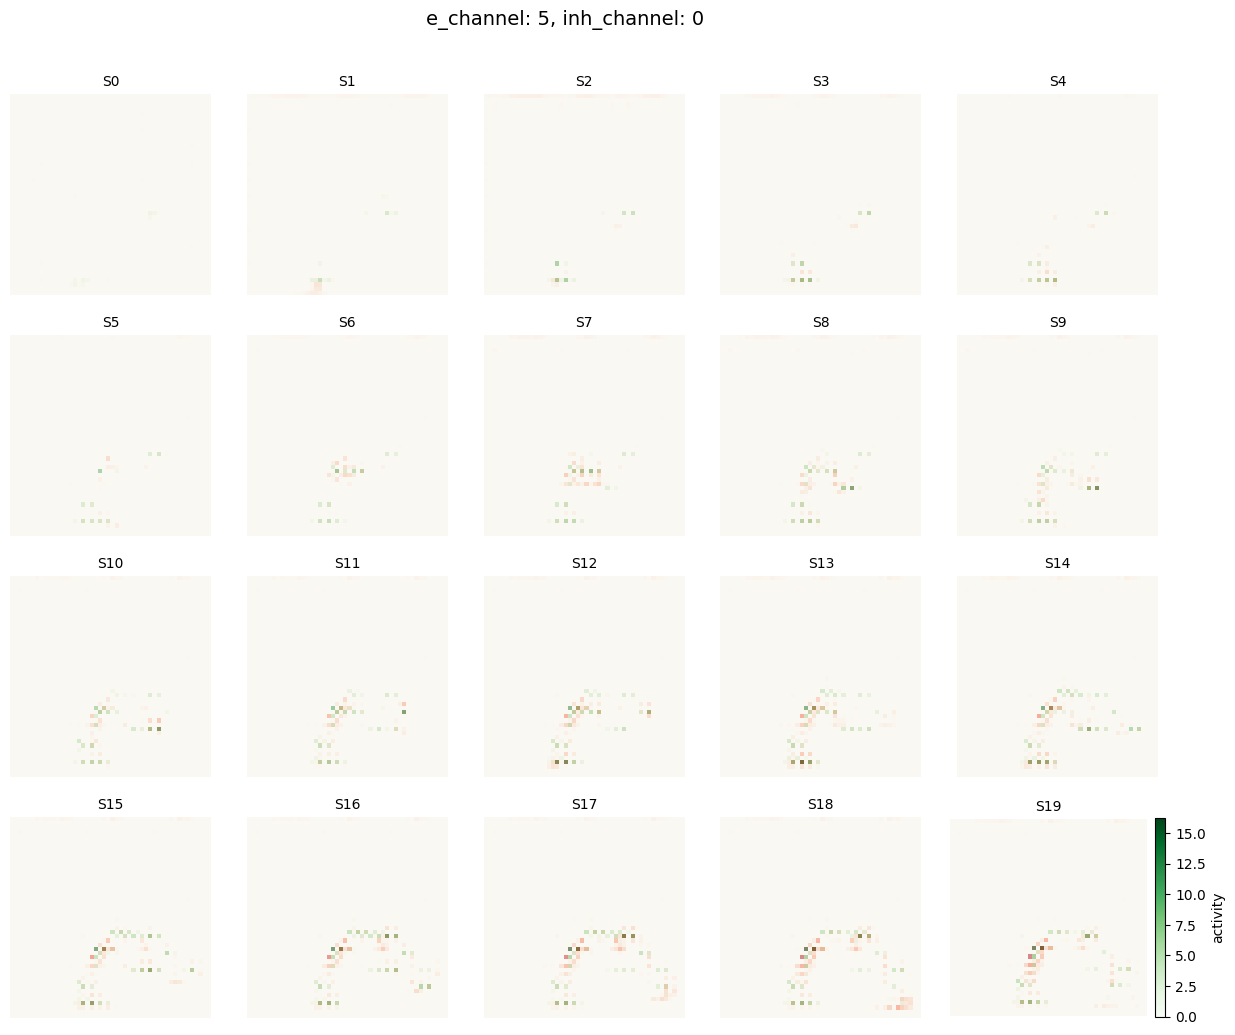

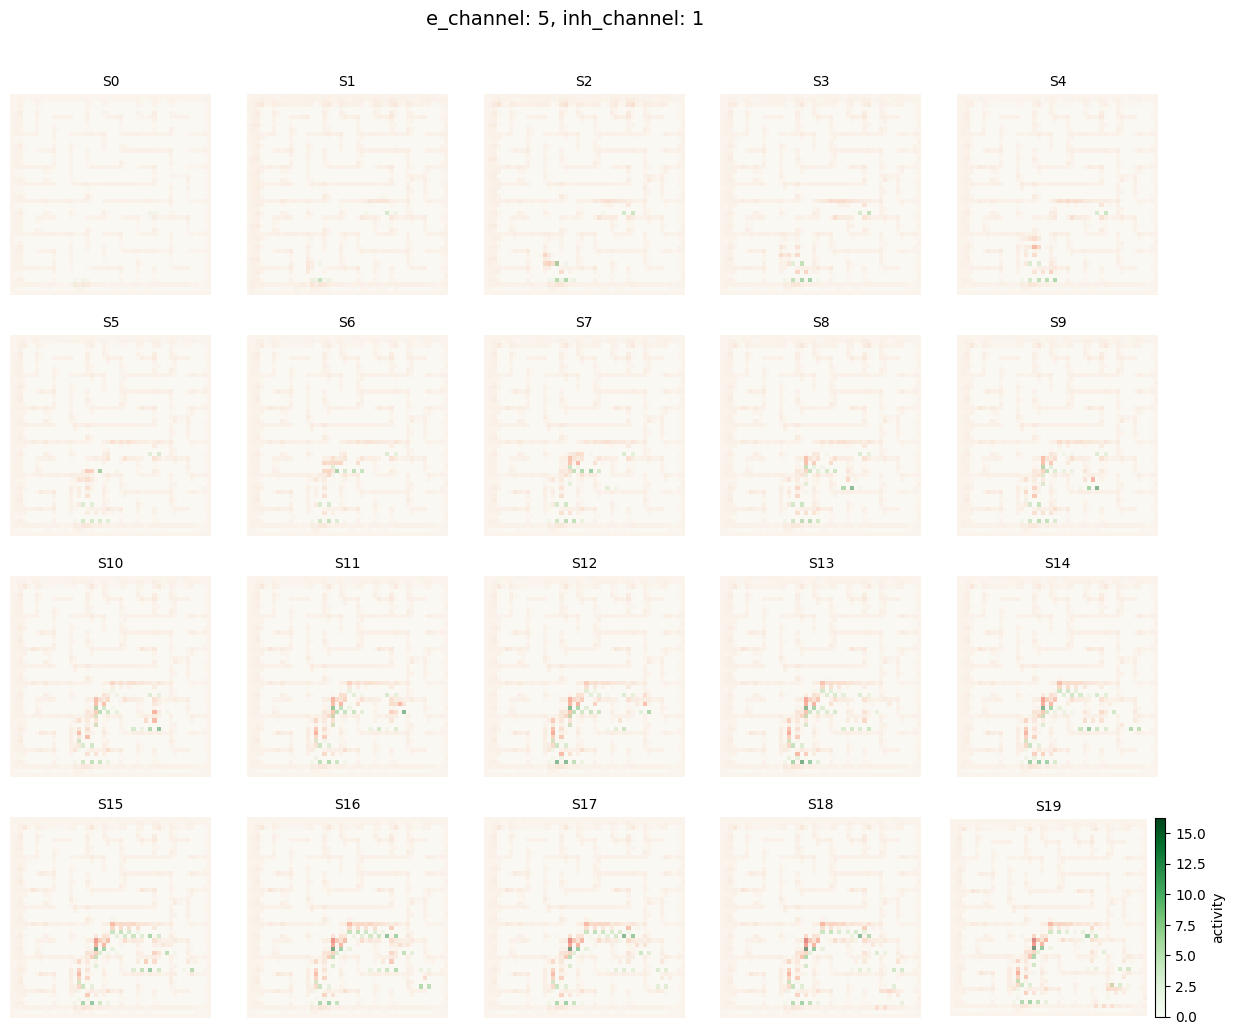

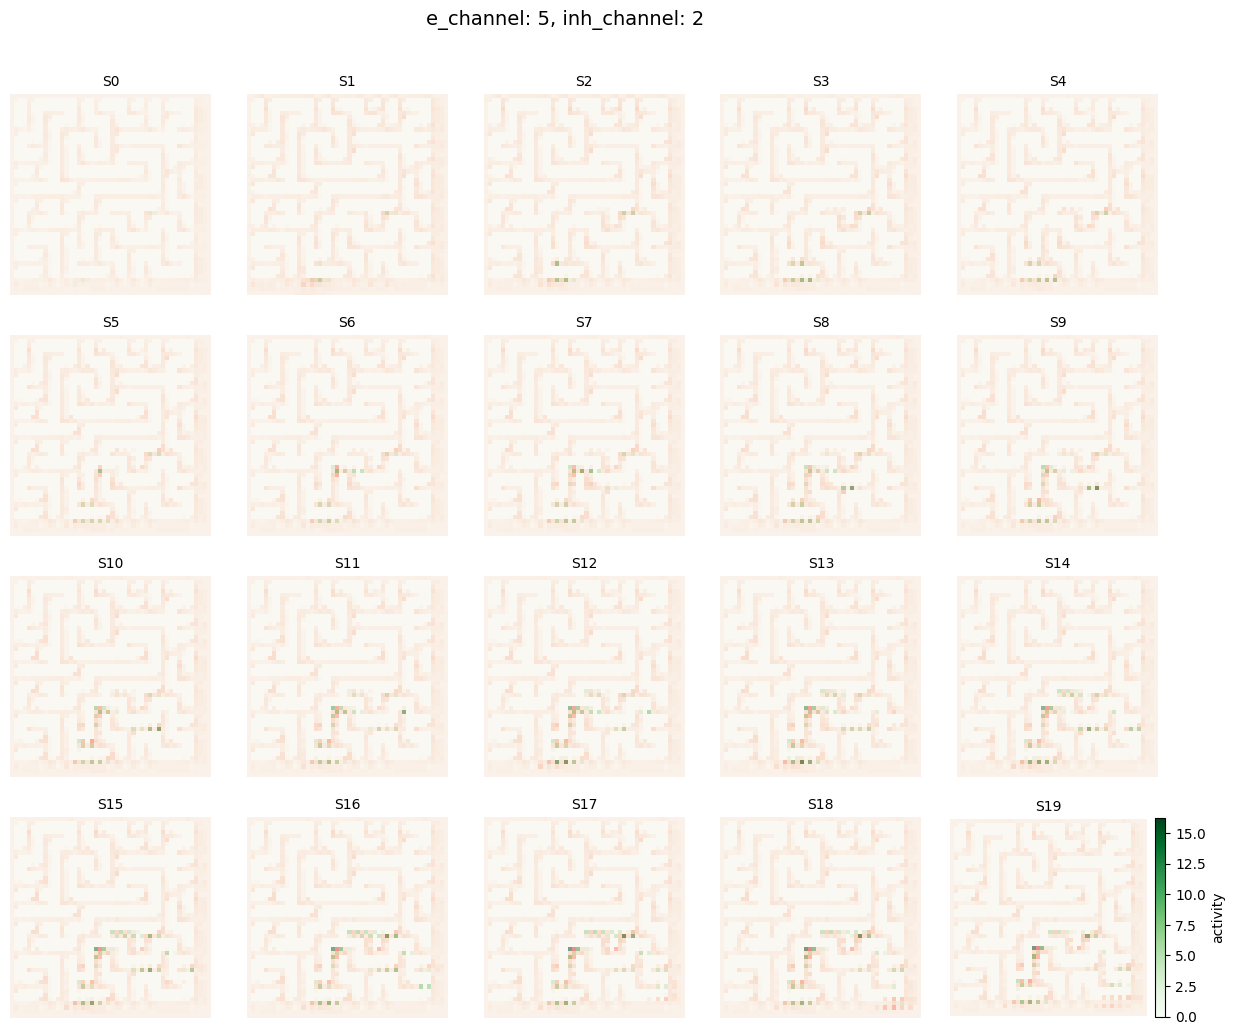

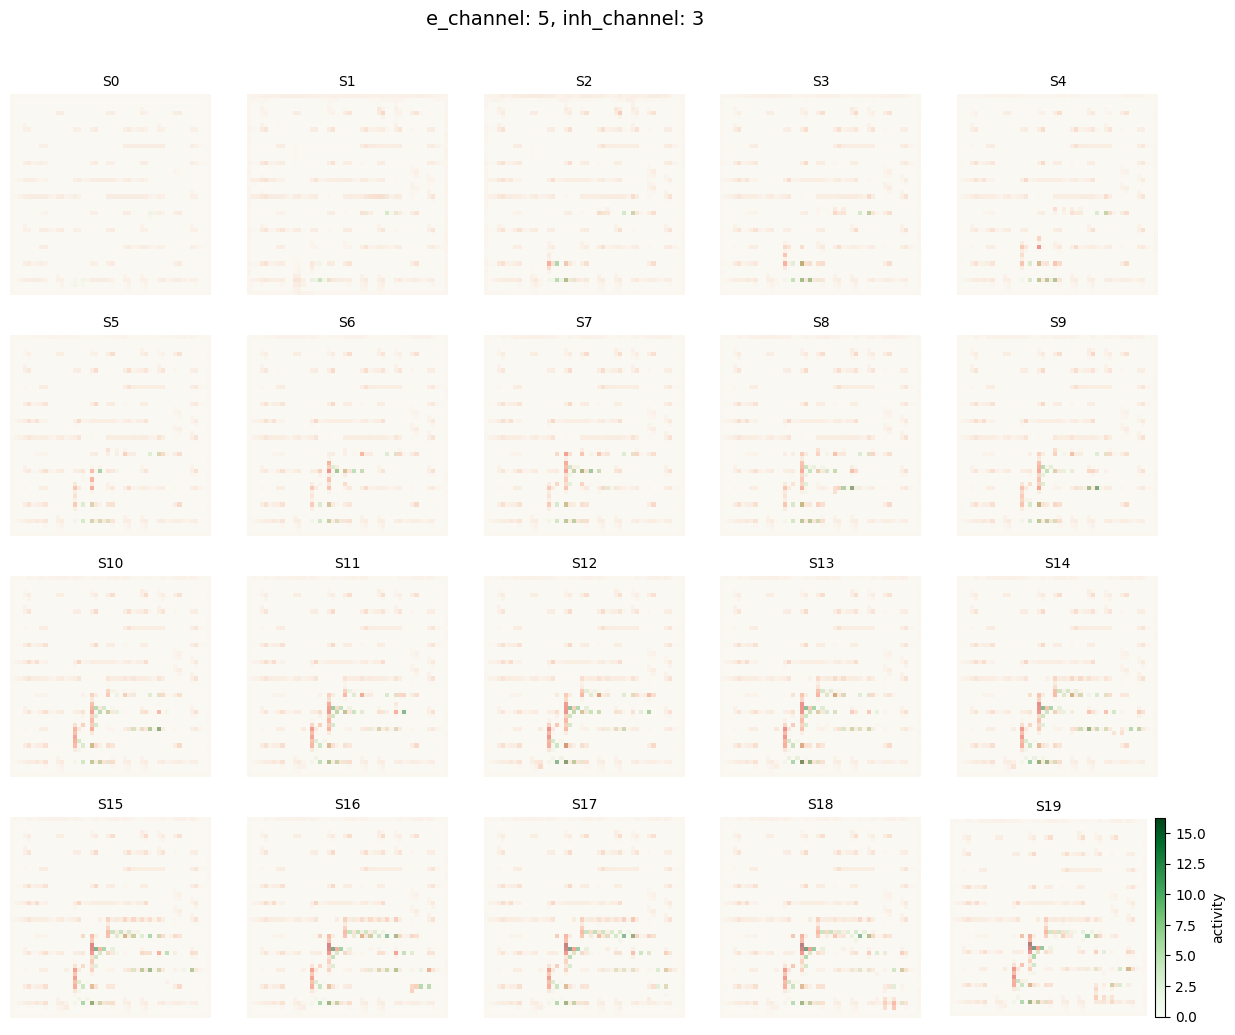

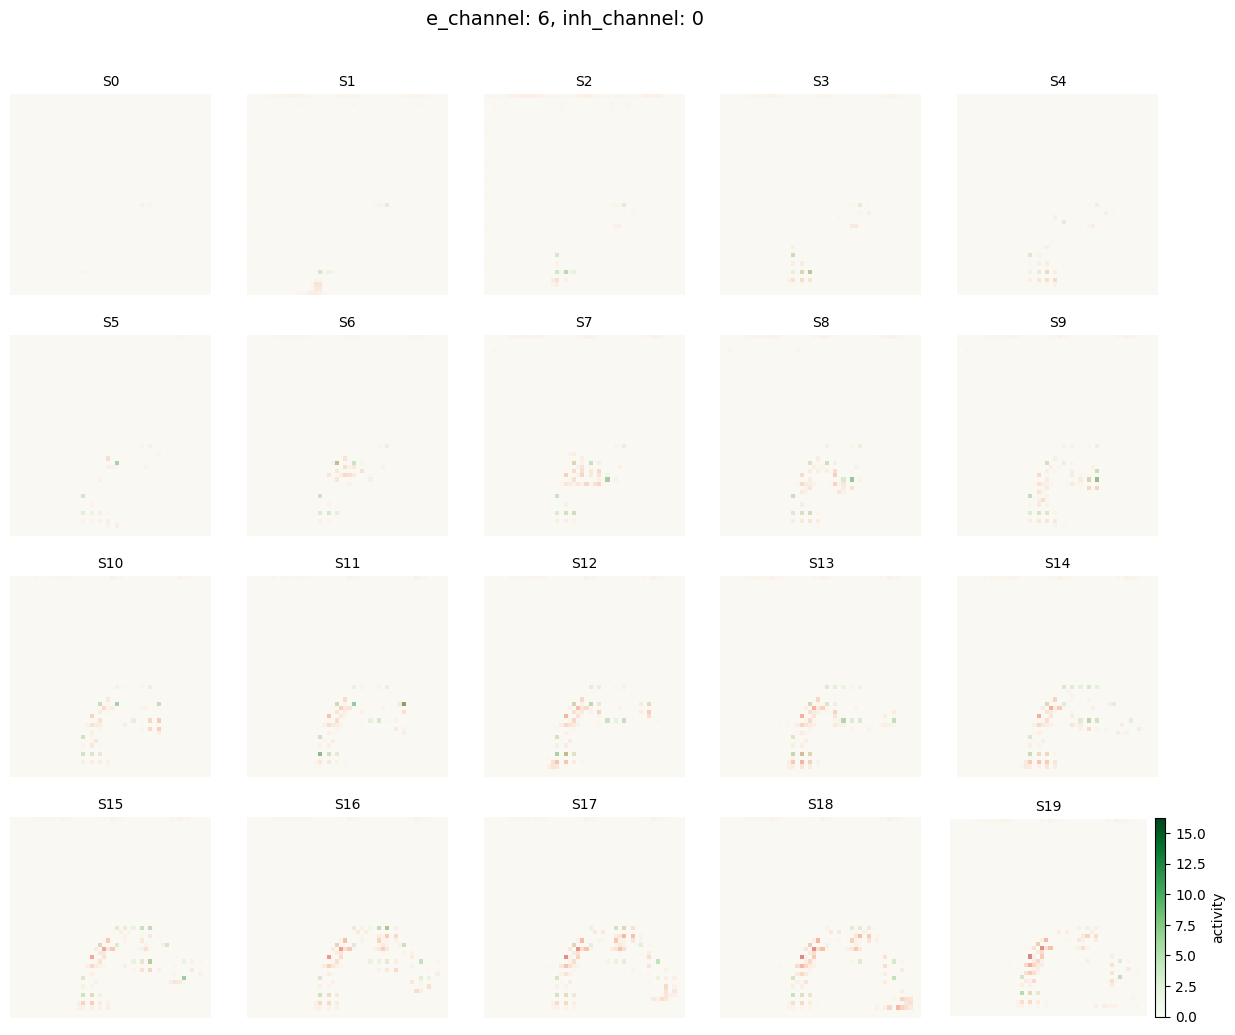

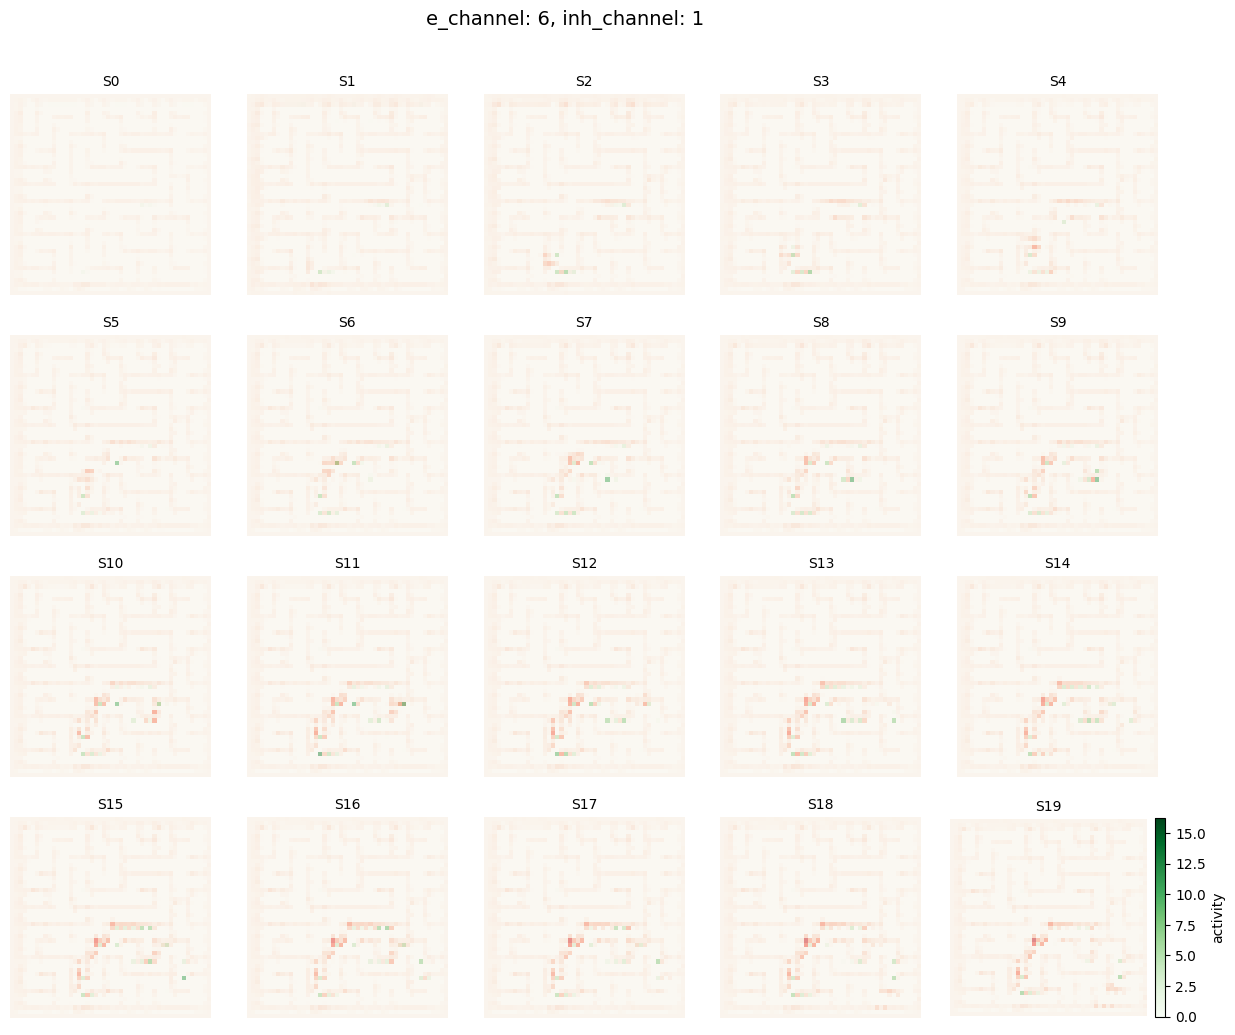

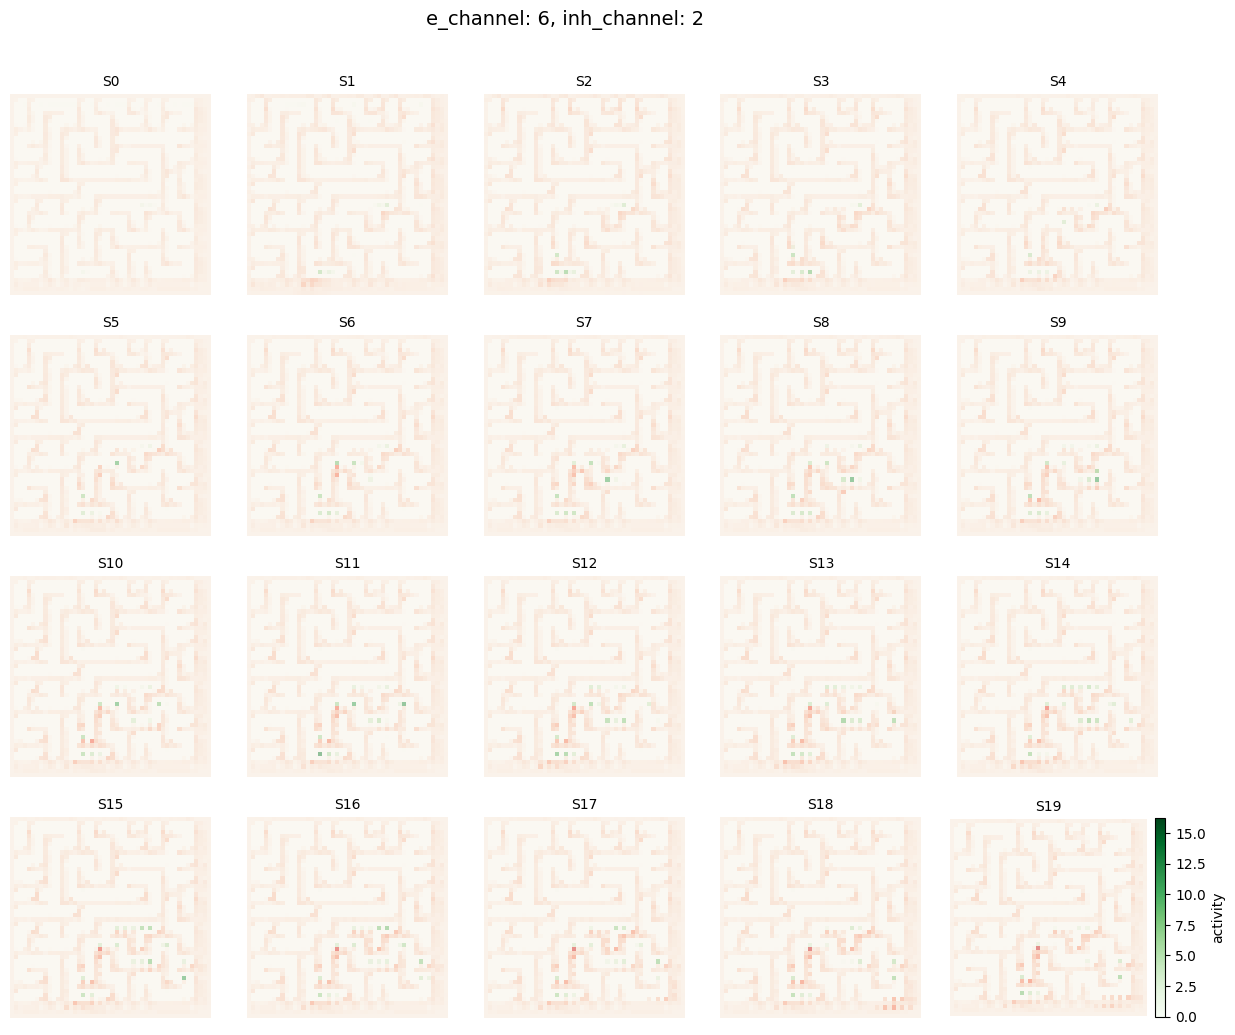

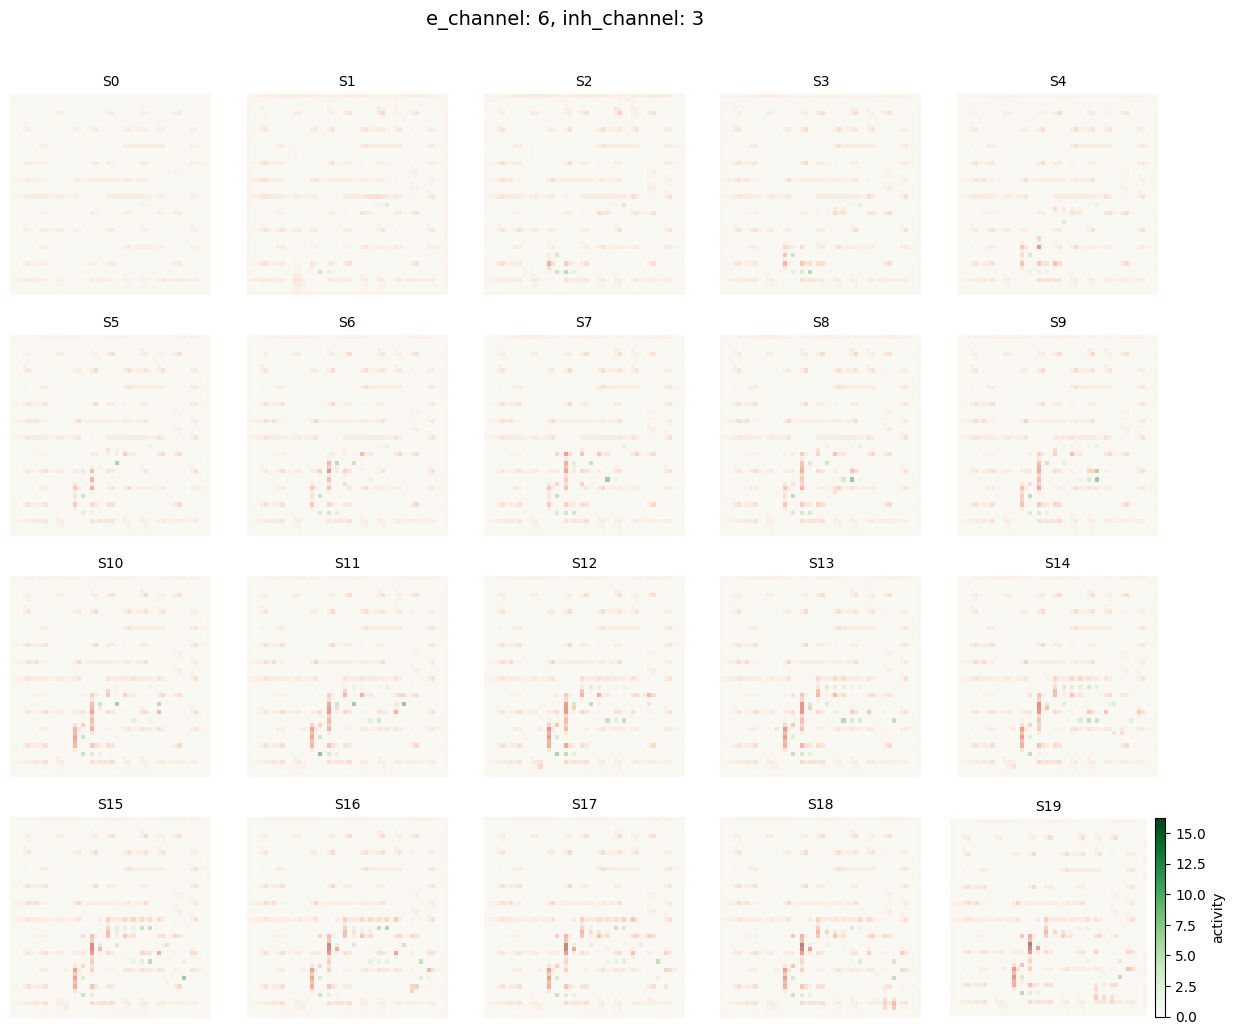

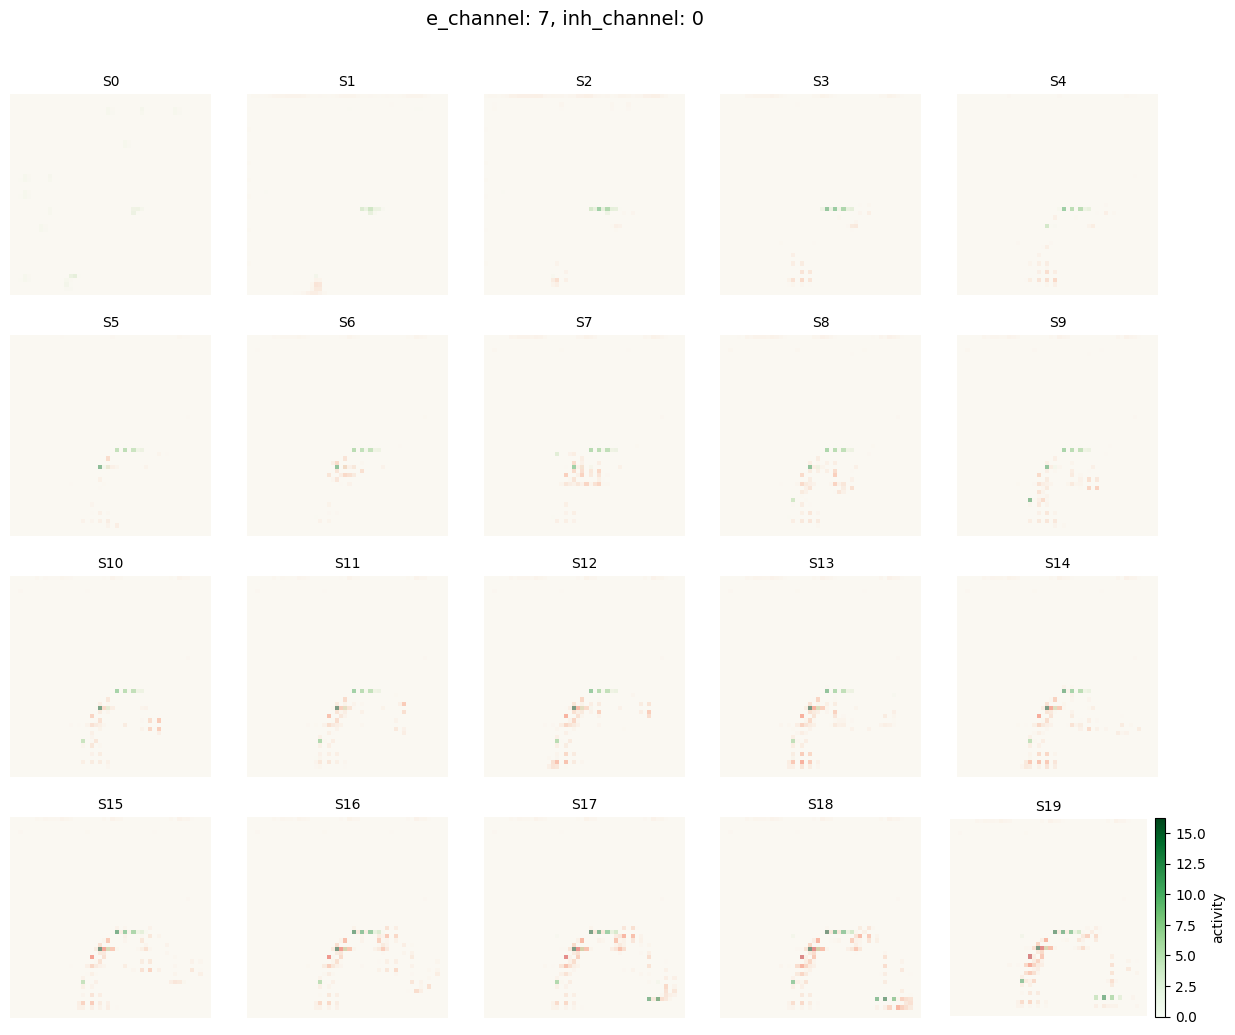

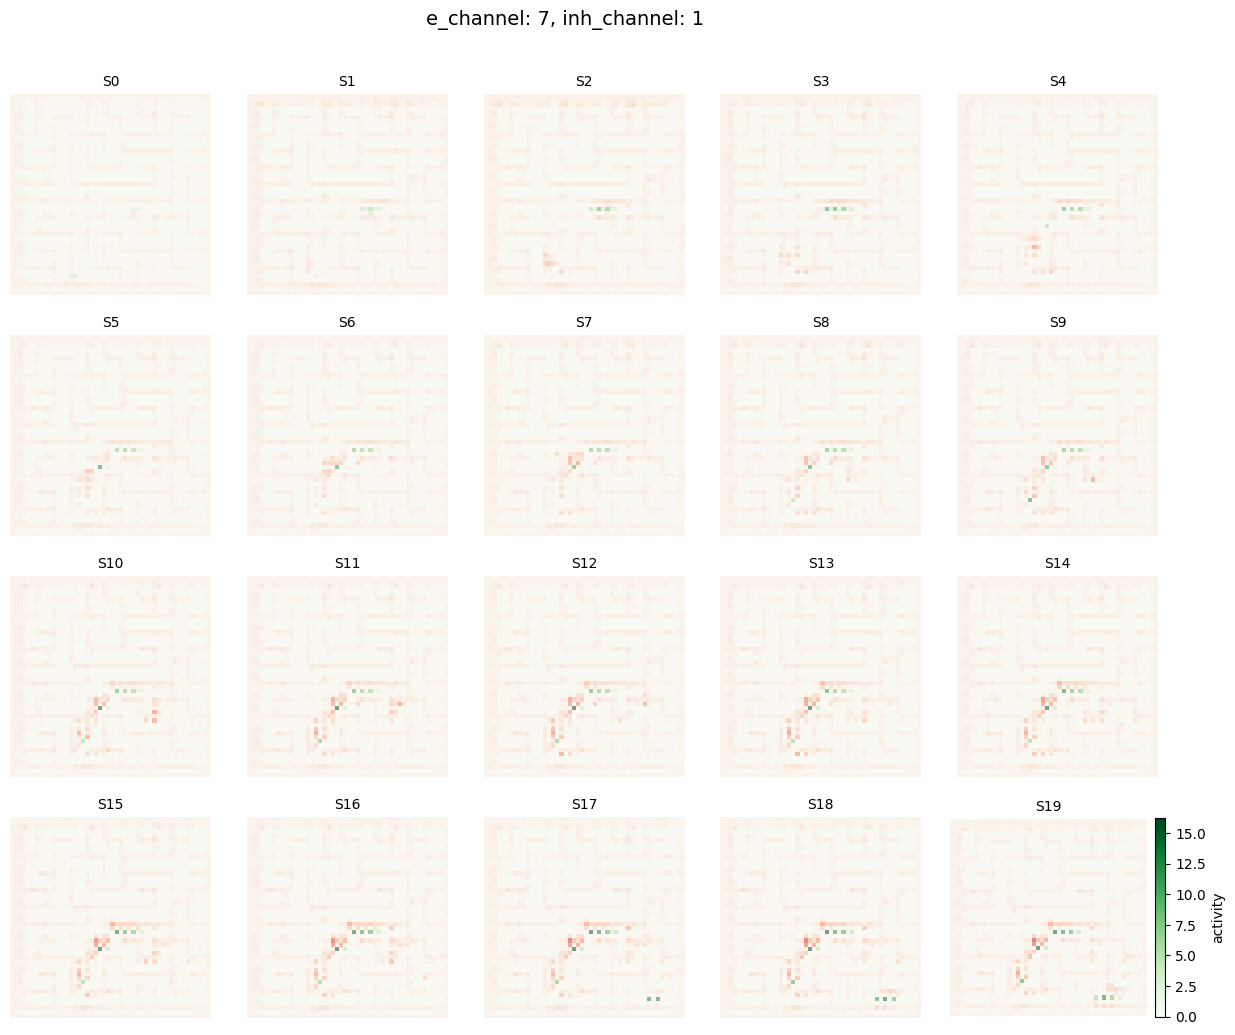

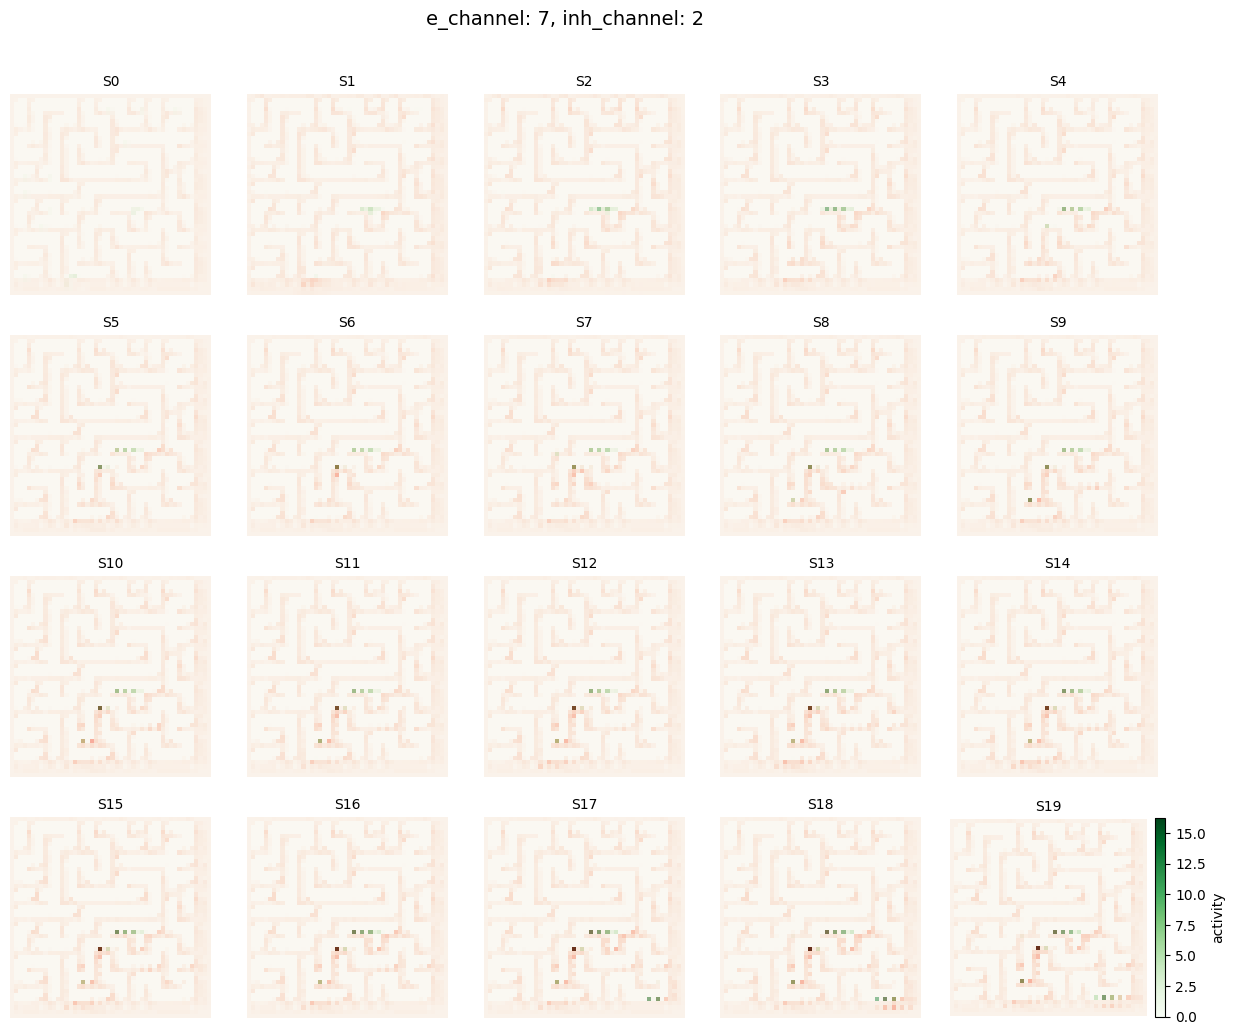

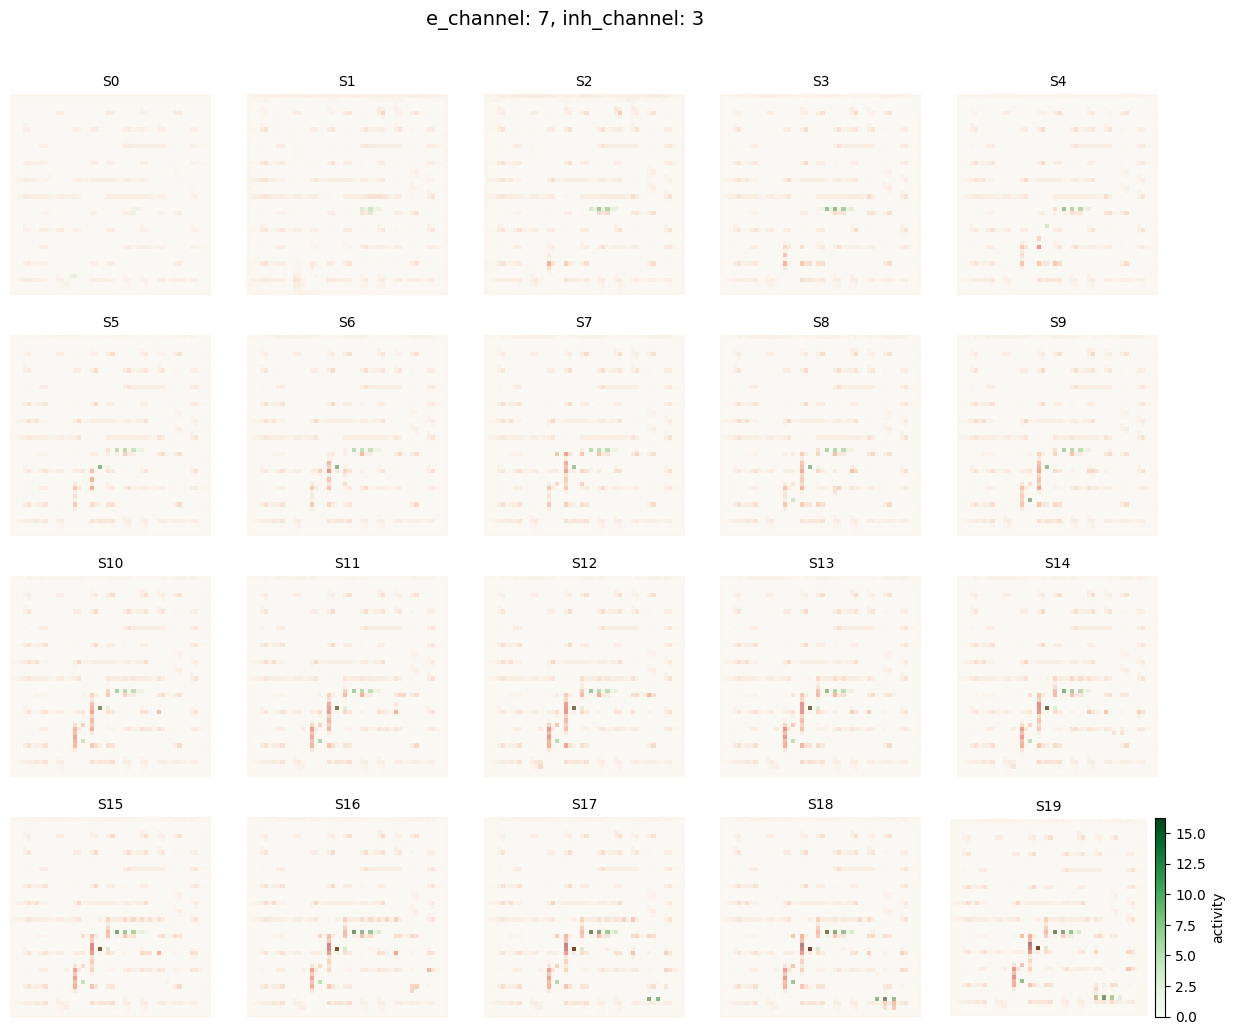

In [115]:
import numpy as np
import matplotlib.pyplot as plt

def plot_activity_overlay_panels(
    ex_activity,     # ndarray[T, H, W]: excitatory frames
    inh_activity,    # ndarray[T, H, W]: inhibitory frames
    e_channel,
    inh_channel,
    n, m,             # ints: grid layout (n rows × m cols)
    alpha=0.5
):
    """
    Plot excitatory (green) and inhibitory (red) activity overlaid
    in a n×m grid. No return; just shows the figure.
    """
    ex_activity = ex_activity[:, e_channel]   # excitatory
    inh_activity = inh_activity[:, inh_channel]   # inhibitory, for example

    T = ex_activity.shape[0]
    step_indices = np.linspace(0, T - 1, n * m, dtype=int)

    # sanity checks
    if ex_activity.shape != inh_activity.shape:
        raise ValueError("ex_activity and inh_activity must have the same shape")
    total = len(step_indices)
    if total > n * m:
        raise ValueError(f"{total} panels won't fit in a {n}×{m} grid")
    
    # compute shared color‐scale over all selected frames
    emin = torch.min(torch.min(ex_activity), torch.min(inh_activity))
    emax = torch.max(torch.max(ex_activity), torch.max(inh_activity))

    # create figure + gridspec
    fig = plt.figure(figsize=(m*3, n*3))
    grid = fig.add_gridspec(n, m, hspace=0.2, wspace=0.1)
    fig.suptitle(f"e_channel: {e_channel}, inh_channel: {inh_channel}", fontsize=14, y=0.95)

    for idx, step in enumerate(step_indices):
        r, c = divmod(idx, m)
        ax = fig.add_subplot(grid[r, c])

        exc = ex_activity[step]
        inh = inh_activity[step]

        # show excitation
        im0 = ax.imshow(exc, cmap="Greens", vmin=vmin, vmax=vmax)
        # overlay inhibition
        im1 = ax.imshow(inh, cmap="Reds", vmin=vmin, vmax=vmax, alpha=alpha)

        ax.set_title(f"S{step}", fontsize=10)
        ax.axis("off")

        # only add one colorbar (here for excitation)
        if idx == total - 1:
            cbar = fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label("activity")

    plt.show()


# ——— Load model config & instantiate ———
model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)

# ——— Load checkpoint & weights ———
state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
model.load_state_dict(prepare_rnn_weights(state_dict))

# ——— Plot settings ———
n, m = 4, 5  # activity grid dims
e_channels = np.arange(0, 8)
inh_channels = np.arange(0, 4)
sample_indices = [7]
do_highlight_self_kernel = False

# Main plotting loop
for plot_idx, sample_idx in enumerate(sample_indices):
    inp, label = inputs[sample_idx], labels[sample_idx]
    _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps)
    exc = model.query_neuron_states(neuron_states, 0, 0) \
                .detach().cpu()[0]  # shape (T, C)
    inh = model.query_neuron_states(neuron_states, 0, 1) \
                .detach().cpu()[0]  # shape (T, C)

    for e_channel in e_channels:
        for inh_channel in inh_channels:
            plot_activity_overlay_panels(
                ex_activity=exc,
                inh_activity=inh,
                e_channel = e_channel,
                inh_channel = inh_channel,
                n=n, m=m
            )